AVISO LEGAL — PROPIEDAD INTELECTUAL

Este material es propiedad intelectual exclusiva de Julián David Flórez Sánchez (LinkedIn). Todos los derechos reservados. Queda terminantemente prohibida su copia, reproducción, distribución, adaptación o uso por cualquier persona natural o jurídica, pública o privada, sin autorización expresa y escrita del autor. El incumplimiento de esta disposición acarrea las sanciones civiles y penales previstas en la Ley 23 de 1982, la Decisión Andina 351 de 1993, los artículos 270-272 del Código Penal Colombiano y los tratados internacionales de propiedad intelectual aplicables. Para solicitar autorización: linkedin.com/in/julianflorezdata

# Guia 07: Redes Recurrentes - RNN y LSTM

## Electiva II - Deep Learning | Tecnologico de Antioquia

---

**Objetivo:** Comprender las redes neuronales recurrentes (RNN) para el procesamiento de datos secuenciales y aplicarlas a la prediccion de series temporales. Exploraremos desde la RNN basica hasta arquitecturas avanzadas como LSTM, GRU, redes apiladas y bidireccionales.

**Conceptos nuevos en esta guia:**
- Datos secuenciales y dependencias temporales
- RNN vanilla (recurrencia y estado oculto)
- Problema del gradiente que desaparece/explota
- LSTM (Long Short-Term Memory) y sus puertas
- GRU (Gated Recurrent Unit)
- Ventanas deslizantes (sliding windows) para series temporales
- Bidirectional RNN
- Prediccion univariable vs. multivariable

**Prerrequisito:** Guia 06 - CNN Avanzado y Transfer Learning

**Duracion estimada:** 3 horas

**GPU recomendada:** Se recomienda usar GPU para acelerar el entrenamiento. Puedes usar Google Colab (Runtime > Change runtime type > GPU) o un entorno local con GPU.

---

> **AVISO - Evaluacion** &#9997;&#65039;
>
> Las celdas marcadas con &#9997;&#65039; requieren tu respuesta escrita. Estas respuestas seran evaluadas como parte de la nota de la guia. Responde de forma clara, completa y en tus propias palabras. Tambien se evaluara la ejecucion correcta de los experimentos y la calidad del analisis.

---

## 1. Configuracion del Entorno

Comenzamos importando las librerias necesarias y configurando el entorno de trabajo.

In [21]:
# ============================================================
# Importaciones principales
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

# Configuracion de graficos
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

TensorFlow version: 2.19.0
Keras version: 3.13.2
NumPy version: 2.0.2
Pandas version: 2.2.2


In [22]:
# ============================================================
# Semilla para reproducibilidad
# ============================================================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Semilla fijada: {SEED}")

Semilla fijada: 42


In [23]:
# ============================================================
# Verificar disponibilidad de GPU
# ============================================================
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"GPU(s) disponible(s): {len(gpus)}")
    for gpu in gpus:
        print(f"  - {gpu.name}")
    # Permitir crecimiento dinamico de memoria GPU
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No se detecto GPU. Se usara CPU.")
    print("Consejo: En Google Colab, ve a Runtime > Change runtime type > GPU")

GPU(s) disponible(s): 1
  - /physical_device:GPU:0


---

## 2. Marco Teorico: Redes Recurrentes

### 2.1 ¿Por que necesitamos un nuevo tipo de red?

En las guias anteriores trabajamos con dos tipos de redes:

- **DNN (Dense Neural Networks):** Procesan datos tabulares donde cada muestra es independiente.
- **CNN (Convolutional Neural Networks):** Procesan datos espaciales (imagenes) detectando patrones locales.

Pero, ¿que pasa cuando los datos tienen un **orden temporal** y cada dato depende de los anteriores?

Piensa en estos ejemplos:
- **Temperatura:** La temperatura de manana depende de la de hoy, ayer, la semana pasada...
- **Texto:** El significado de una palabra depende de las palabras anteriores ("el banco del parque" vs "el banco de dinero")
- **Audio:** Un sonido se entiende en el contexto de los sonidos previos
- **Video:** Cada fotograma se relaciona con los anteriores

Estos son **datos secuenciales**: datos donde el **orden importa** y existe una **dependencia temporal**.

| Tipo de dato | Red adecuada | ¿Tiene memoria? |
|---|---|---|
| Tabular (filas independientes) | DNN | No |
| Imagenes (patrones espaciales) | CNN | No |
| Secuencias (dependencias temporales) | **RNN** | **Si** |

**El problema fundamental:** Las DNN y CNN procesan cada entrada de forma **independiente**. No tienen "memoria" de lo que vieron antes. Necesitamos una red que pueda **recordar** informacion de pasos anteriores.

### 2.2 RNN Vanilla: La idea de la recurrencia

La **Red Neuronal Recurrente (RNN)** resuelve este problema con una idea elegante: **la red se retroalimenta a si misma**. En cada paso temporal, la RNN:

1. Recibe la entrada actual $x_t$
2. Recibe el estado oculto del paso anterior $h_{t-1}$ (la "memoria")
3. Produce un nuevo estado oculto $h_t$ y una salida

#### Diagrama de una RNN (version compacta vs desenrollada)

**Version compacta:**
```
        +-------+
  x_t ->|       |-> y_t
        |  RNN  |
  h_t <-|       |<- h_{t-1}
        +-------+
           |  ^
           +--+  (lazo de retroalimentacion)
```

**Version desenrollada en el tiempo (3 pasos):**
```
  x_0          x_1          x_2
   |            |            |
   v            v            v
+------+   +------+   +------+
|      |-->|      |-->|      |
| RNN  |   | RNN  |   | RNN  |  (mismos pesos W en cada paso)
|      |   |      |   |      |
+------+   +------+   +------+
   |  h_0-->  |  h_1-->  |  h_2
   v          v          v
  y_0        y_1        y_2
```

**Punto clave:** Es la **misma red** (mismos pesos) aplicada en cada paso temporal. El estado oculto $h_t$ actua como la "memoria" que pasa informacion de un paso al siguiente.

#### Formula matematica de la RNN Vanilla

$$h_t = \tanh(W_{hh} \cdot h_{t-1} + W_{xh} \cdot x_t + b_h)$$

$$y_t = W_{hy} \cdot h_t + b_y$$

Donde:
- $x_t$: entrada en el paso temporal $t$
- $h_t$: estado oculto en el paso $t$ (la "memoria")
- $h_{t-1}$: estado oculto del paso anterior
- $W_{hh}$: pesos de la conexion recurrente (hidden-to-hidden)
- $W_{xh}$: pesos de la entrada (input-to-hidden)
- $W_{hy}$: pesos de la salida (hidden-to-output)
- $b_h$, $b_y$: sesgos
- $\tanh$: funcion de activacion (aplasta valores entre -1 y 1)

### 2.3 El problema del gradiente que desaparece (y explota)

La RNN vanilla tiene un problema grave: cuando la secuencia es larga, la informacion del inicio **se pierde**.

#### ¿Por que ocurre?

Durante el entrenamiento (backpropagation through time - BPTT), los gradientes se propagan hacia atras en el tiempo. En cada paso, se multiplican por la matriz de pesos $W_{hh}$:

$$\frac{\partial L}{\partial h_0} = \frac{\partial L}{\partial h_T} \cdot \prod_{t=1}^{T} \frac{\partial h_t}{\partial h_{t-1}}$$

Cada factor $\frac{\partial h_t}{\partial h_{t-1}}$ involucra la derivada de $\tanh$ (que esta entre 0 y 1) multiplicada por $W_{hh}$.

- Si estos valores son **menores que 1**: al multiplicar muchas veces, el producto tiende a **0** (gradiente que **desaparece**).
- Si estos valores son **mayores que 1**: al multiplicar muchas veces, el producto tiende a **infinito** (gradiente que **explota**).

#### Analogia: El telefono descompuesto

Imagina un juego de telefono descompuesto con 50 personas en fila:
- La primera persona dice un mensaje.
- Cada persona le susurra el mensaje a la siguiente.
- Al llegar a la persona 50, el mensaje esta completamente **distorsionado** o se ha **perdido**.

Eso es exactamente lo que pasa con la RNN vanilla: la informacion del inicio de la secuencia se **degrada** al pasar por muchos pasos temporales.

```
Paso 1: "La temperatura subio"    ---> Gradiente: 1.0
Paso 5: "La temperatura subio"    ---> Gradiente: 0.5
Paso 10: "...temperatura..."      ---> Gradiente: 0.1
Paso 20: "...algo..."             ---> Gradiente: 0.001
Paso 50: "???"                    ---> Gradiente: 0.0000001 (casi cero!)
```

**Consecuencia practica:** La RNN vanilla solo puede aprender dependencias a **corto plazo** (5-10 pasos). No puede recordar informacion de hace muchos pasos.

### 2.4 LSTM: La solucion elegante

La **Long Short-Term Memory (LSTM)** fue propuesta por Hochreiter y Schmidhuber en 1997 para resolver el problema del gradiente que desaparece.

#### La analogia de la cinta transportadora

Imagina una **cinta transportadora** en una fabrica:
- La cinta (estado de celda $C_t$) lleva informacion de un extremo a otro **sin modificarla**.
- En ciertos puntos, hay **puertas** que pueden:
  - **Forget gate (puerta de olvido):** Decidir que informacion **quitar** de la cinta.
  - **Input gate (puerta de entrada):** Decidir que informacion **nueva agregar** a la cinta.
  - **Output gate (puerta de salida):** Decidir que informacion de la cinta **usar como salida**.

```
            Puerta de       Puerta de        Puerta de
             Olvido          Entrada           Salida
               |               |                 |
               v               v                 v
C_{t-1} --[x olvidar]--[+ agregar nuevo]------[salida]--> C_t
               ^               ^                 ^
               |               |                 |
          h_{t-1}, x_t    h_{t-1}, x_t      h_{t-1}, x_t
```

La clave es que el **estado de celda** $C_t$ puede transportar informacion a traves de muchos pasos temporales sin degradarse, porque solo se le aplican operaciones **lineales** (multiplicacion y suma), no funciones de activacion compresivas repetidas.

#### Formulas de la LSTM

**1. Puerta de Olvido (Forget Gate):** ¿Que informacion del pasado debemos olvidar?

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

Produce valores entre 0 (olvidar completamente) y 1 (recordar completamente).

**2. Puerta de Entrada (Input Gate):** ¿Que informacion nueva debemos guardar?

$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

$i_t$ decide **cuanto** guardar, $\tilde{C}_t$ son los **valores candidatos** a guardar.

**3. Actualizacion del estado de celda:** Olvidar lo viejo + agregar lo nuevo.

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

Donde $\odot$ es la multiplicacion elemento a elemento (Hadamard product).

**4. Puerta de Salida (Output Gate):** ¿Que parte del estado usamos como salida?

$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(C_t)$$

#### ¿Por que funciona?

El gradiente fluye a traves del estado de celda $C_t$ casi sin modificarse:

$$\frac{\partial C_t}{\partial C_{t-1}} = f_t$$

Si la puerta de olvido $f_t \approx 1$, el gradiente pasa **intacto**. La red aprende **cuando olvidar y cuando recordar**, en lugar de perder informacion inevitablemente.

#### Numero de parametros

Una capa LSTM con $n$ unidades y entrada de dimension $m$ tiene:

$$\text{parametros} = 4 \times [(n + m) \times n + n] = 4 \times [n^2 + mn + n]$$

El factor 4 viene de las 4 matrices de pesos (forget, input, candidato, output).

### 2.5 GRU: Version simplificada de LSTM

La **Gated Recurrent Unit (GRU)** fue propuesta por Cho et al. en 2014 como una simplificacion de la LSTM. Tiene solo **2 puertas** en lugar de 3:

**1. Puerta de Reset:** ¿Cuanto del estado anterior considerar para el candidato?

$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)$$

**2. Puerta de Update:** ¿Cuanto del estado anterior mantener vs cuanto del nuevo usar?

$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)$$

**3. Candidato y estado final:**

$$\tilde{h}_t = \tanh(W_h \cdot [r_t \odot h_{t-1}, x_t] + b_h)$$
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

#### Diferencias clave: LSTM vs GRU

| Caracteristica | LSTM | GRU |
|---|---|---|
| Puertas | 3 (forget, input, output) | 2 (reset, update) |
| Estado | Celda ($C_t$) + Oculto ($h_t$) | Solo oculto ($h_t$) |
| Parametros | 4(n^2 + mn + n) | 3(n^2 + mn + n) |
| Velocidad | Mas lenta | Mas rapida |
| Rendimiento | Mejor en secuencias largas | Similar en secuencias cortas |

**¿Cuando usar cual?**
- **LSTM:** Cuando las secuencias son largas y las dependencias lejanas son importantes.
- **GRU:** Cuando tienes datos limitados, necesitas velocidad, o las secuencias son cortas/medianas.
- En la practica, la diferencia suele ser pequena. Se recomienda probar ambas.

### 2.6 Ventanas deslizantes (Sliding Windows)

Para usar una RNN/LSTM en prediccion de series temporales, necesitamos transformar la serie en pares **(X, y)** para aprendizaje supervisado.

La tecnica de **ventana deslizante** funciona asi:

Dada una serie temporal: `[10, 12, 15, 13, 17, 20, 18, ...]`

Con una ventana de tamanio 3 (usamos 3 pasos pasados para predecir el siguiente):

```
Ventana (X)       -> Objetivo (y)
[10, 12, 15]      -> 13
[12, 15, 13]      -> 17
[15, 13, 17]      -> 20
[13, 17, 20]      -> 18
...
```

La ventana se "desliza" un paso a la vez, creando multiples ejemplos de entrenamiento a partir de una sola serie.

**Formato de entrada para RNN/LSTM en Keras:**
- X tiene forma: `(num_muestras, pasos_temporales, num_features)`
- Para serie univariable: `(num_muestras, tamanio_ventana, 1)`
- Para serie multivariable: `(num_muestras, tamanio_ventana, num_variables)`

### 2.7 Bidirectional RNN

Una **RNN Bidireccional** procesa la secuencia en **ambas direcciones**:
- Una RNN lee de izquierda a derecha (pasado -> futuro)
- Otra RNN lee de derecha a izquierda (futuro -> pasado)
- Las salidas de ambas se concatenan

```
  x_0       x_1       x_2       x_3
   |         |         |         |
   v         v         v         v
 [RNN->]--[RNN->]--[RNN->]--[RNN->]   (forward)
   |         |         |         |
 [<-RNN]--[<-RNN]--[<-RNN]--[<-RNN]   (backward)
   |         |         |         |
   v         v         v         v
 [concat] [concat] [concat] [concat]  (concatenar ambas direcciones)
```

**Utilidad:** Es muy potente para tareas donde tenemos **acceso a toda la secuencia** (ej. clasificacion de texto, traduccion). Sin embargo, para **prediccion de series temporales**, no tiene sentido leer el futuro porque... ¡no lo conocemos al momento de predecir! Aun asi, lo exploraremos como experimento didactico.

**Nota:** Una Bidirectional LSTM con $n$ unidades produce una salida de dimension $2n$ (concatenacion de ambas direcciones).

---

## 3. Carga y Exploracion de Datos

Usaremos el **dataset Jena Climate**, un dataset muy conocido en el campo de series temporales. Contiene datos meteorologicos registrados cada **10 minutos** en la estacion meteorologica del Instituto Max Planck de Biogeoquimica en Jena, Alemania.

Las variables incluyen:
- Temperatura del aire
- Presion atmosferica
- Humedad relativa
- Direccion y velocidad del viento
- Y otras variables meteorologicas

In [24]:
import os
import glob
import keras
import pandas as pd

# Descargar el dataset Jena Climate
zip_path = keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip',
    extract=True
)

# Buscar el CSV dentro del directorio extraído
extracted_dir = zip_path.replace('.zip', '_extracted')
found = glob.glob(os.path.join(extracted_dir, '**', '*.csv'), recursive=True)

csv_path = found[0]
print(f"CSV encontrado en: {csv_path}")

# Cargar con pandas
df = pd.read_csv(csv_path)

print(f"Forma del dataset: {df.shape}")
print(f"Numero de registros: {len(df):,}")
print(f"\nColumnas:")
for col in df.columns:
    print(f"  - {col}")

CSV encontrado en: /root/.keras/datasets/jena_climate_2009_2016_extracted/jena_climate_2009_2016.csv
Forma del dataset: (420551, 15)
Numero de registros: 420,551

Columnas:
  - Date Time
  - p (mbar)
  - T (degC)
  - Tpot (K)
  - Tdew (degC)
  - rh (%)
  - VPmax (mbar)
  - VPact (mbar)
  - VPdef (mbar)
  - sh (g/kg)
  - H2OC (mmol/mol)
  - rho (g/m**3)
  - wv (m/s)
  - max. wv (m/s)
  - wd (deg)


In [25]:
# ============================================================
# Explorar las primeras filas
# ============================================================
print("Primeras 10 filas del dataset:")
df.head(10)

Primeras 10 filas del dataset:


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
5,01.01.2009 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
6,01.01.2009 01:10:00,996.50,-7.62,265.81,-8.30,94.8,3.44,3.26,0.18,2.04,3.27,1305.68,0.18,0.63,166.5
7,01.01.2009 01:20:00,996.50,-7.62,265.81,-8.36,94.4,3.44,3.25,0.19,2.03,3.26,1305.69,0.19,0.50,118.6
8,01.01.2009 01:30:00,996.50,-7.91,265.52,-8.73,93.8,3.36,3.15,0.21,1.97,3.16,1307.17,0.28,0.75,188.5
9,01.01.2009 01:40:00,996.53,-8.43,264.99,-9.34,93.1,3.23,3.00,0.22,1.88,3.02,1309.85,0.59,0.88,185.0


In [26]:
# ============================================================
# Estadisticas descriptivas
# ============================================================
print("Estadisticas descriptivas:")
df.describe().round(2)

Estadisticas descriptivas:


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00
mean,989.21,9.45,283.49,4.96,76.01,13.58,9.53,4.04,6.02,9.64,1216.06,1.70,3.06,174.74
std,8.36,8.42,8.50,6.73,16.48,7.74,4.18,4.90,2.66,4.24,39.98,65.45,69.02,86.68
min,913.60,-23.01,250.60,-25.01,12.95,0.95,0.79,0.00,0.50,0.80,1059.45,-9999.00,-9999.00,0.00
25%,984.20,3.36,277.43,0.24,65.21,7.78,6.21,0.87,3.92,6.29,1187.49,0.99,1.76,124.90
50%,989.58,9.42,283.47,5.22,79.30,11.82,8.86,2.19,5.59,8.96,1213.79,1.76,2.96,198.10
75%,994.72,15.47,289.53,10.07,89.40,17.60,12.35,5.30,7.80,12.49,1242.77,2.86,4.74,234.10
max,1015.35,37.28,311.34,23.11,100.00,63.77,28.32,46.01,18.13,28.82,1393.54,28.49,23.50,360.00


In [27]:
# ============================================================
# Verificar valores nulos
# ============================================================
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nTotal de valores nulos: {df.isnull().sum().sum()}")

Valores nulos por columna:
Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

Total de valores nulos: 0


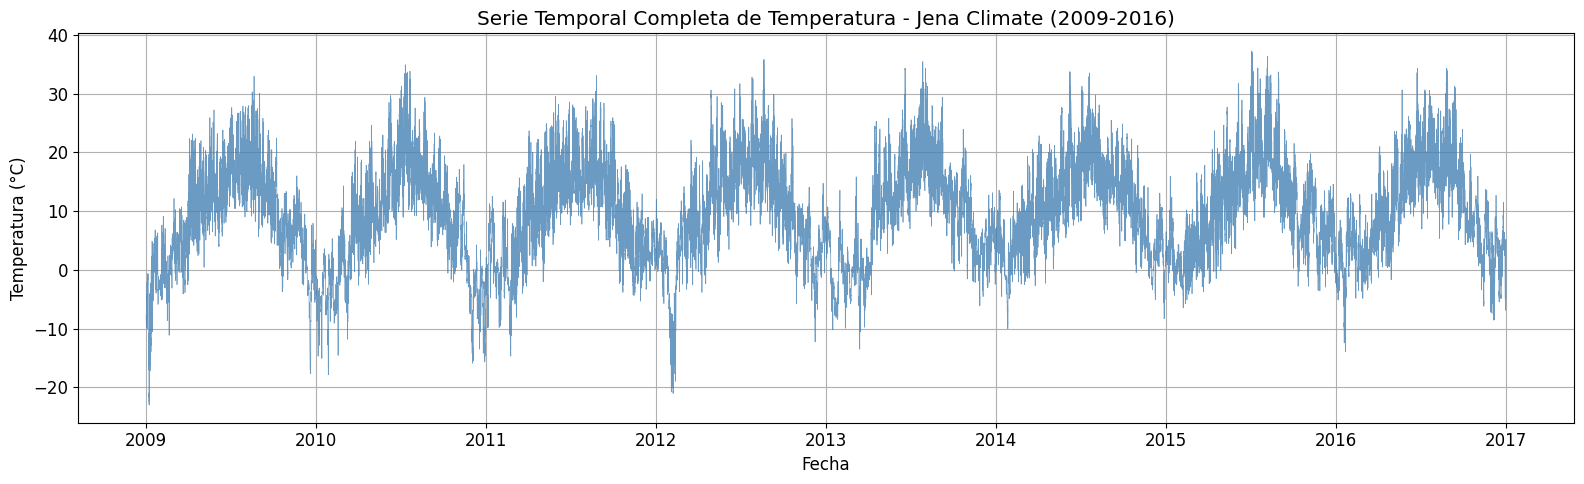

Periodo: 2009-01-01 00:10:00 a 2017-01-01 00:00:00
Rango de temperatura: -23.0°C a 37.3°C


In [28]:
# ============================================================
# Graficar la serie temporal completa de temperatura
# ============================================================
fig, ax = plt.subplots(figsize=(16, 5))

fechas = pd.to_datetime(df['Date Time'], dayfirst=True)

ax.plot(fechas, df['T (degC)'], linewidth=0.5, alpha=0.8, color='steelblue')
ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.set_title('Serie Temporal Completa de Temperatura - Jena Climate (2009-2016)')
plt.tight_layout()
plt.show()

print(f"Periodo: {fechas.iloc[0]} a {fechas.iloc[-1]}")
print(f"Rango de temperatura: {df['T (degC)'].min():.1f}°C a {df['T (degC)'].max():.1f}°C")

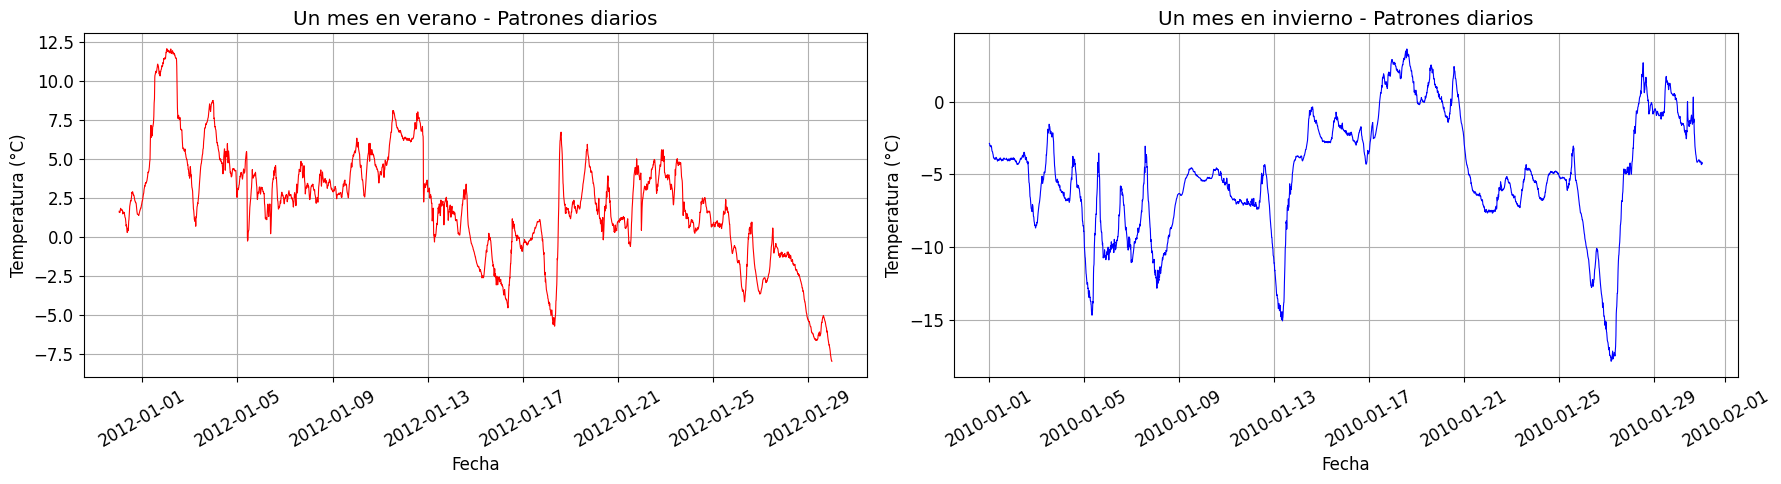

Observa los patrones ciclicos diarios (la temperatura sube de dia y baja de noche).


In [29]:
# ============================================================
# Zoom: visualizar un mes para ver patrones diarios
# ============================================================
# Un mes tiene aprox. 30 dias * 24 horas * 6 muestras/hora = 4320 muestras
muestras_mes = 30 * 24 * 6  # 4320

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Mes de verano (julio)
inicio_verano = 3 * 365 * 24 * 6  # Aprox. julio de algun anio
axes[0].plot(fechas.iloc[inicio_verano:inicio_verano+muestras_mes],
             df['T (degC)'].iloc[inicio_verano:inicio_verano+muestras_mes],
             linewidth=0.8, color='red')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].set_title('Un mes en verano - Patrones diarios')
axes[0].tick_params(axis='x', rotation=30)

# Mes de invierno (enero)
inicio_invierno = 365 * 24 * 6  # Aprox. enero
axes[1].plot(fechas.iloc[inicio_invierno:inicio_invierno+muestras_mes],
             df['T (degC)'].iloc[inicio_invierno:inicio_invierno+muestras_mes],
             linewidth=0.8, color='blue')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Temperatura (°C)')
axes[1].set_title('Un mes en invierno - Patrones diarios')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("Observa los patrones ciclicos diarios (la temperatura sube de dia y baja de noche).")

In [30]:
# ============================================================
# Submuestrear: tomar una lectura cada hora (cada 6 registros)
# ============================================================
# El dataset original tiene lecturas cada 10 minutos.
# Para hacerlo mas manejable, tomamos una lectura cada hora (cada 6 registros).

PASO_SUBMUESTREO = 6  # Cada 6 registros = 1 hora

df_hourly = df[::PASO_SUBMUESTREO].reset_index(drop=True)

print(f"Dataset original: {len(df):,} registros (cada 10 min)")
print(f"Dataset submuestreado: {len(df_hourly):,} registros (cada 1 hora)")
print(f"\nPrimeras filas del dataset submuestreado:")
df_hourly.head()

Dataset original: 420,551 registros (cada 10 min)
Dataset submuestreado: 70,092 registros (cada 1 hora)

Primeras filas del dataset submuestreado:


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 01:10:00,996.50,-7.62,265.81,-8.30,94.8,3.44,3.26,0.18,2.04,3.27,1305.68,0.18,0.63,166.5
2,01.01.2009 02:10:00,996.63,-8.85,264.57,-9.70,93.5,3.12,2.92,0.20,1.82,2.93,1312.11,0.16,0.50,158.3
3,01.01.2009 03:10:00,996.87,-8.84,264.56,-9.69,93.5,3.13,2.92,0.20,1.83,2.93,1312.37,0.07,0.25,129.3
4,01.01.2009 04:10:00,997.05,-9.23,264.15,-10.25,92.2,3.03,2.79,0.24,1.74,2.80,1314.62,0.10,0.38,203.9


### &#9997;&#65039; Pregunta 1

**¿Que patrones observas en la serie temporal de temperatura? ¿Hay estacionalidad? Describe al menos dos patrones que identifiques y explica su origen.**

### &#9997;&#65039; Tu respuesta:

*Escribe aqui tu respuesta...*

---

## 4. Experimentacion Guiada

Ahora vamos a construir y comparar diferentes modelos para predecir la temperatura de la proxima hora, dado un historial de las horas anteriores.

### Experimento 1: Preparar datos con ventanas deslizantes

Antes de construir cualquier modelo, necesitamos transformar nuestra serie temporal en pares (X, y) usando la tecnica de ventana deslizante.

**Plan:**
1. Seleccionar la columna de temperatura
2. Crear la funcion de ventana deslizante
3. Hacer split cronologico (train/val/test)
4. Normalizar los datos

In [31]:
# ============================================================
# Extraer la serie de temperatura (univariable por ahora)
# ============================================================
temperatura = df_hourly['T (degC)'].values.astype(np.float32)

print(f"Longitud de la serie de temperatura: {len(temperatura):,} horas")
print(f"Equivalente a: {len(temperatura)/24:.0f} dias = {len(temperatura)/(24*365):.1f} anios")

Longitud de la serie de temperatura: 70,092 horas
Equivalente a: 2920 dias = 8.0 anios


In [32]:
# ============================================================
# Funcion para crear ventanas deslizantes
# ============================================================
def crear_ventanas(serie, tamano_ventana, horizonte=1):
    """
    Transforma una serie temporal en pares (X, y) usando ventanas deslizantes.

    Parametros:
    - serie: array 1D o 2D con la serie temporal
    - tamano_ventana: numero de pasos temporales pasados a usar como entrada
    - horizonte: cuantos pasos adelante predecir (default=1)

    Retorna:
    - X: array de forma (num_muestras, tamano_ventana, num_features)
    - y: array de forma (num_muestras,)
    """
    # Si la serie es 1D, agregar dimension de features
    if serie.ndim == 1:
        serie = serie.reshape(-1, 1)

    X, y_out = [], []
    for i in range(len(serie) - tamano_ventana - horizonte + 1):
        # Ventana de entrada: todas las features
        X.append(serie[i : i + tamano_ventana])
        # Objetivo: solo la temperatura (primera columna) en el paso futuro
        y_out.append(serie[i + tamano_ventana + horizonte - 1, 0])

    return np.array(X), np.array(y_out)

print("Funcion crear_ventanas() definida correctamente.")

Funcion crear_ventanas() definida correctamente.


In [33]:
# ============================================================
# Ejemplo visual de como funcionan las ventanas
# ============================================================
ejemplo = np.array([10, 12, 15, 13, 17, 20, 18, 22, 19, 16], dtype=np.float32)
X_ej, y_ej = crear_ventanas(ejemplo, tamano_ventana=3, horizonte=1)

print("Serie original:", ejemplo)
print(f"\nVentana de tamanio 3, prediciendo 1 paso adelante:")
print(f"{'Ventana (X)':<25} -> {'Objetivo (y)':<10}")
print("-" * 40)
for i in range(len(X_ej)):
    print(f"{str(X_ej[i].flatten()):<25} -> {y_ej[i]}")

print(f"\nForma de X: {X_ej.shape}  (muestras, pasos, features)")
print(f"Forma de y: {y_ej.shape}  (muestras,)")

Serie original: [10. 12. 15. 13. 17. 20. 18. 22. 19. 16.]

Ventana de tamanio 3, prediciendo 1 paso adelante:
Ventana (X)               -> Objetivo (y)
----------------------------------------
[10. 12. 15.]             -> 13.0
[12. 15. 13.]             -> 17.0
[15. 13. 17.]             -> 20.0
[13. 17. 20.]             -> 18.0
[17. 20. 18.]             -> 22.0
[20. 18. 22.]             -> 19.0
[18. 22. 19.]             -> 16.0

Forma de X: (7, 3, 1)  (muestras, pasos, features)
Forma de y: (7,)  (muestras,)


Total de datos: 70,092 horas
Train: 49,064 horas (70.0%)
Val:   10,513 horas (15.0%)
Test:  10,515 horas (15.0%)


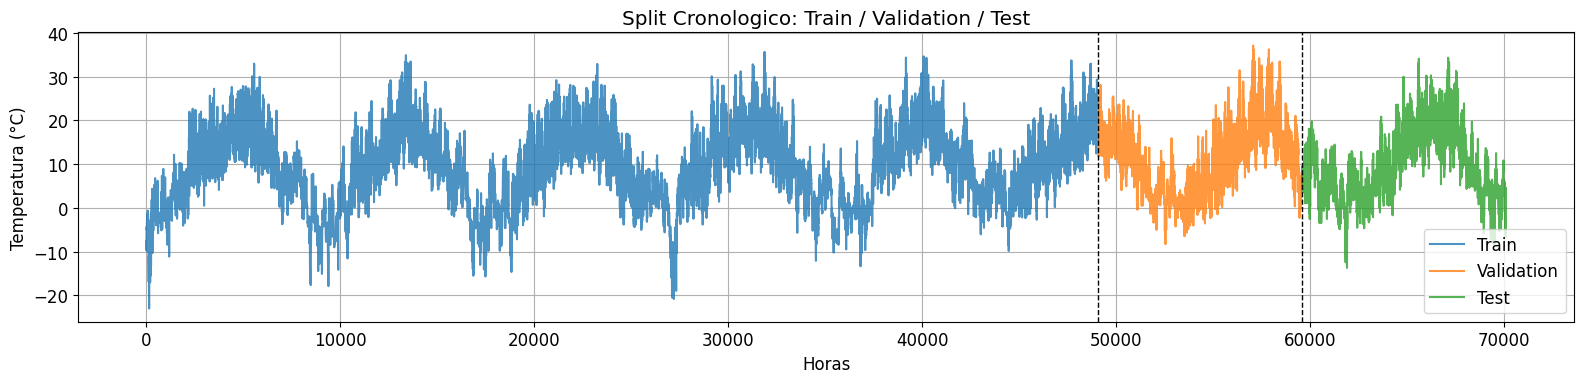

In [34]:
# ============================================================
# Split CRONOLOGICO: Train / Validation / Test
# ============================================================
# MUY IMPORTANTE: En series temporales, el split debe ser cronologico!
# No podemos mezclar datos del futuro en el entrenamiento.
#
# Usaremos:
#   - Train: primeros 70% de los datos
#   - Validation: siguiente 15%
#   - Test: ultimo 15%

n = len(temperatura)
n_train = int(n * 0.70)
n_val = int(n * 0.15)
n_test = n - n_train - n_val

temp_train = temperatura[:n_train]
temp_val = temperatura[n_train:n_train + n_val]
temp_test = temperatura[n_train + n_val:]

print(f"Total de datos: {n:,} horas")
print(f"Train: {len(temp_train):,} horas ({len(temp_train)/n*100:.1f}%)")
print(f"Val:   {len(temp_val):,} horas ({len(temp_val)/n*100:.1f}%)")
print(f"Test:  {len(temp_test):,} horas ({len(temp_test)/n*100:.1f}%)")

# Visualizar el split
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(range(len(temp_train)), temp_train, label='Train', alpha=0.8)
ax.plot(range(len(temp_train), len(temp_train)+len(temp_val)), temp_val, label='Validation', alpha=0.8)
ax.plot(range(len(temp_train)+len(temp_val), n), temp_test, label='Test', alpha=0.8)
ax.axvline(x=len(temp_train), color='black', linestyle='--', linewidth=1)
ax.axvline(x=len(temp_train)+len(temp_val), color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Horas')
ax.set_ylabel('Temperatura (°C)')
ax.set_title('Split Cronologico: Train / Validation / Test')
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# Normalizar con StandardScaler (ajustar SOLO en train)
# ============================================================
scaler = StandardScaler()

# Ajustar solo con datos de entrenamiento (para evitar data leakage)
temp_train_norm = scaler.fit_transform(temp_train.reshape(-1, 1)).flatten()
temp_val_norm = scaler.transform(temp_val.reshape(-1, 1)).flatten()
temp_test_norm = scaler.transform(temp_test.reshape(-1, 1)).flatten()

print(f"Media del scaler (de train): {scaler.mean_[0]:.2f}")
print(f"Std del scaler (de train): {scaler.scale_[0]:.2f}")
print(f"\nTrain normalizado - Media: {temp_train_norm.mean():.4f}, Std: {temp_train_norm.std():.4f}")
print(f"Val normalizado   - Media: {temp_val_norm.mean():.4f}, Std: {temp_val_norm.std():.4f}")
print(f"Test normalizado  - Media: {temp_test_norm.mean():.4f}, Std: {temp_test_norm.std():.4f}")

Media del scaler (de train): 9.11
Std del scaler (de train): 8.66

Train normalizado - Media: 0.0000, Std: 1.0000
Val normalizado   - Media: 0.2130, Std: 0.8962
Test normalizado  - Media: 0.0505, Std: 0.8987


In [36]:
# ============================================================
# Crear las ventanas deslizantes para train, val, test
# ============================================================
TAMANO_VENTANA = 24  # Usar las ultimas 24 horas para predecir la siguiente

X_train, y_train = crear_ventanas(temp_train_norm, TAMANO_VENTANA)
X_val, y_val = crear_ventanas(temp_val_norm, TAMANO_VENTANA)
X_test, y_test = crear_ventanas(temp_test_norm, TAMANO_VENTANA)

print(f"Tamano de ventana: {TAMANO_VENTANA} horas")
print(f"\nFormas de los datos:")
print(f"  X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}  y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}  y_test:  {y_test.shape}")
print(f"\nInterpretacion de X_train shape {X_train.shape}:")
print(f"  - {X_train.shape[0]:,} muestras de entrenamiento")
print(f"  - {X_train.shape[1]} pasos temporales (horas) por muestra")
print(f"  - {X_train.shape[2]} feature(s) por paso temporal")

Tamano de ventana: 24 horas

Formas de los datos:
  X_train: (49040, 24, 1)  y_train: (49040,)
  X_val:   (10489, 24, 1)  y_val:   (10489,)
  X_test:  (10491, 24, 1)  y_test:  (10491,)

Interpretacion de X_train shape (49040, 24, 1):
  - 49,040 muestras de entrenamiento
  - 24 pasos temporales (horas) por muestra
  - 1 feature(s) por paso temporal


### &#9997;&#65039; Pregunta 2

**¿Por que es importante hacer el split cronologicamente y no aleatorio? ¿Que problema causaria un split aleatorio en datos de series temporales?**

### &#9997;&#65039; Tu respuesta:

*Escribe aqui tu respuesta...*

In [37]:
# ============================================================
# Funcion auxiliar para entrenar y evaluar modelos
# ============================================================
def entrenar_modelo(modelo, X_train, y_train, X_val, y_val, epochs=30, batch_size=64, verbose=1):
    """
    Entrena un modelo y retorna el historial y el tiempo de entrenamiento.
    """
    # Callback para detener si no mejora
    early_stop = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    inicio = time.time()

    historial = modelo.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=verbose
    )

    tiempo = time.time() - inicio

    return historial, tiempo


def evaluar_modelo(modelo, X_test, y_test, scaler, nombre="Modelo"):
    """
    Evalua un modelo en el conjunto de test.
    Retorna MAE en escala original (grados Celsius).
    """
    # Predicciones en escala normalizada
    y_pred_norm = modelo.predict(X_test, verbose=0).flatten()

    # Desnormalizar para obtener MAE en grados Celsius
    y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_original = scaler.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()

    mae = np.mean(np.abs(y_test_original - y_pred_original))

    print(f"\n{nombre}:")
    print(f"  MAE (test): {mae:.4f} °C")
    print(f"  Parametros: {modelo.count_params():,}")

    return mae, y_pred_original, y_test_original


def graficar_historial(historial, titulo=""):
    """
    Grafica las curvas de perdida de entrenamiento.
    """
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(historial.history['loss'], label='Train Loss')
    ax.plot(historial.history['val_loss'], label='Val Loss')
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Loss (MSE)')
    ax.set_title(f'Curvas de Entrenamiento - {titulo}')
    ax.legend()
    plt.tight_layout()
    plt.show()


def graficar_predicciones(y_real, y_pred, titulo="", n_puntos=200):
    """
    Grafica predicciones vs valores reales en un segmento.
    """
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(y_real[:n_puntos], label='Valor Real', linewidth=1.5, alpha=0.8)
    ax.plot(y_pred[:n_puntos], label='Prediccion', linewidth=1.5, alpha=0.8, linestyle='--')
    ax.set_xlabel('Horas')
    ax.set_ylabel('Temperatura (°C)')
    ax.set_title(f'Predicciones vs Valores Reales - {titulo}')
    ax.legend()
    plt.tight_layout()
    plt.show()


# Diccionario para almacenar resultados de todos los modelos
resultados = {}

print("Funciones auxiliares definidas correctamente.")

Funciones auxiliares definidas correctamente.


---

### Experimento 2: Baseline con modelo denso (DNN)

Antes de usar RNN, establecemos un **baseline** con una red densa clasica. La idea es simple:
1. Aplanar la ventana de 24 horas en un vector de 24 valores.
2. Pasar por capas Dense.
3. Predecir el siguiente valor de temperatura.

Este baseline nos dira: **¿puede una red sin memoria temporal capturar patrones en series temporales?**

In [38]:
# ============================================================
# Modelo Baseline: Red Densa (DNN)
# ============================================================
# Para una DNN, necesitamos aplanar la entrada
# X_train tiene forma (muestras, 24, 1) -> aplanar a (muestras, 24)

modelo_dnn = models.Sequential([
    layers.Flatten(input_shape=(TAMANO_VENTANA, 1)),  # (24, 1) -> (24,)
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # Salida: prediccion de temperatura
], name='DNN_Baseline')

modelo_dnn.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

modelo_dnn.summary()

Model: "DNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# ============================================================
# Entrenar el modelo DNN
# ============================================================
print("Entrenando modelo DNN (baseline)...")
hist_dnn, tiempo_dnn = entrenar_modelo(modelo_dnn, X_train, y_train, X_val, y_val, epochs=30)
print(f"\nTiempo de entrenamiento: {tiempo_dnn:.1f} segundos")

Entrenando modelo DNN (baseline)...
Epoch 1/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0292 - mae: 0.1063 - val_loss: 0.0097 - val_mae: 0.0694
Epoch 2/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0092 - mae: 0.0689 - val_loss: 0.0086 - val_mae: 0.0641
Epoch 3/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0085 - mae: 0.0657 - val_loss: 0.0083 - val_mae: 0.0623
Epoch 4/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0083 - mae: 0.0646 - val_loss: 0.0081 - val_mae: 0.0613
Epoch 5/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0081 - mae: 0.0638 - val_loss: 0.0080 - val_mae: 0.0608
Epoch 6/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0080 - mae: 0.0633 - val_loss: 0.0079 - val_mae: 0.0604
Epoch 7/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0079 - mae: 0.0628 - val_loss: 0.0078 - val_mae: 0.0599
Epoch 8/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0079 - mae: 0.0624 - val_loss: 0.0078 - val_mae: 0.0600
Epoch 9/30
767/767 ━

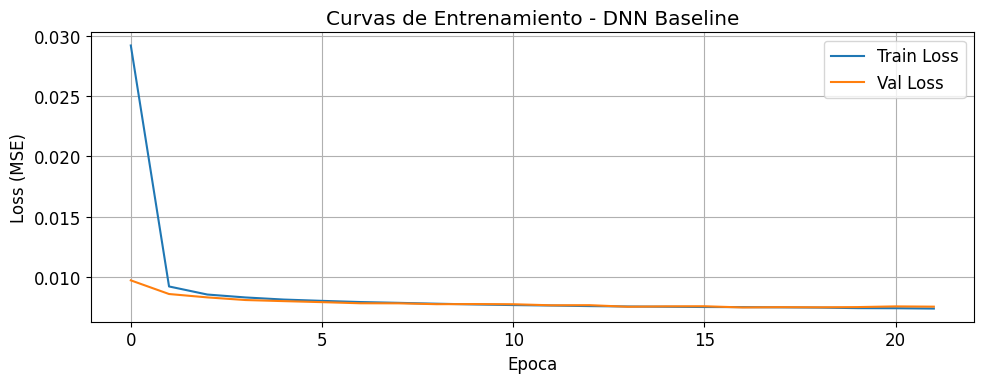


DNN Baseline:
  MAE (test): 0.4797 °C
  Parametros: 3,713


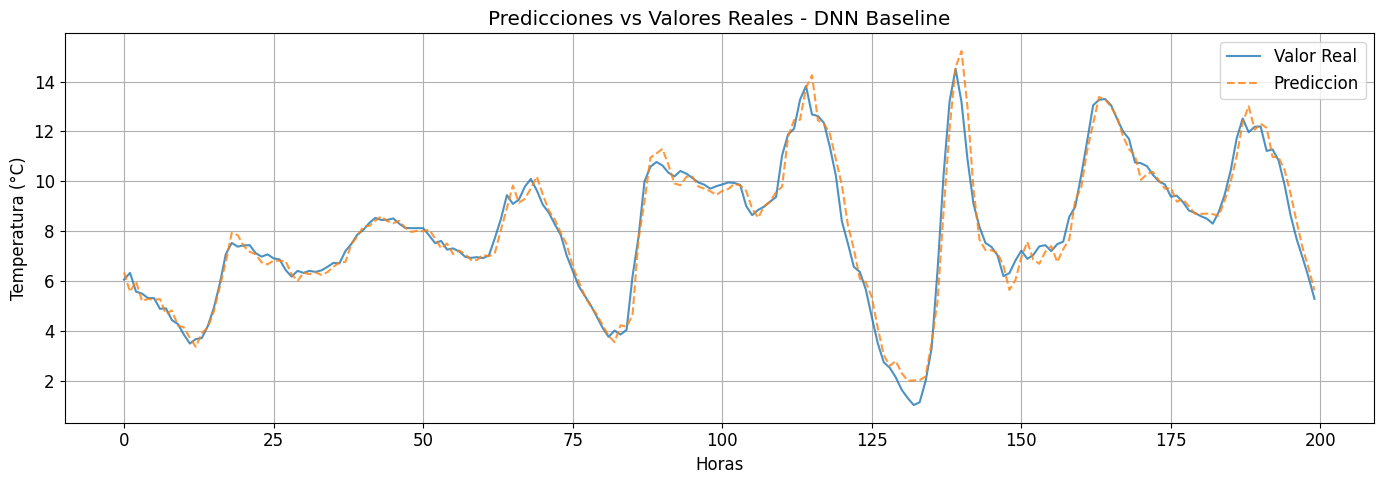

In [40]:
# ============================================================
# Evaluar el modelo DNN
# ============================================================
graficar_historial(hist_dnn, titulo='DNN Baseline')

mae_dnn, pred_dnn, real_dnn = evaluar_modelo(modelo_dnn, X_test, y_test, scaler, nombre='DNN Baseline')
resultados['DNN Baseline'] = {'MAE': mae_dnn, 'Parametros': modelo_dnn.count_params(), 'Tiempo': tiempo_dnn}

graficar_predicciones(real_dnn, pred_dnn, titulo='DNN Baseline', n_puntos=200)

### &#9997;&#65039; Pregunta 3

**¿Que MAE obtuvo el modelo denso (DNN)? Anota este valor ya que lo usaremos como referencia para comparar con las redes recurrentes.**

### &#9997;&#65039; Tu respuesta:

*Escribe aqui tu respuesta...*

---

### Experimento 3: RNN Simple (SimpleRNN)

Ahora construimos nuestra primera red recurrente usando `SimpleRNN`. Esta es la RNN vanilla que vimos en la teoria: aplica la misma operacion en cada paso temporal, pasando el estado oculto de un paso al siguiente.

La diferencia clave con la DNN es que la SimpleRNN **procesa la secuencia paso a paso**, manteniendo un estado interno que se actualiza con cada nueva hora de datos.

In [41]:
# ============================================================
# Modelo: SimpleRNN
# ============================================================
modelo_rnn = models.Sequential([
    # SimpleRNN con 32 unidades
    # input_shape = (pasos_temporales, features) = (24, 1)
    layers.SimpleRNN(32, input_shape=(TAMANO_VENTANA, 1)),
    layers.Dense(1)  # Salida: prediccion de temperatura
], name='SimpleRNN')

modelo_rnn.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

modelo_rnn.summary()

Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# ============================================================
# Entrenar SimpleRNN
# ============================================================
print("Entrenando modelo SimpleRNN...")
hist_rnn, tiempo_rnn = entrenar_modelo(modelo_rnn, X_train, y_train, X_val, y_val, epochs=30)
print(f"\nTiempo de entrenamiento: {tiempo_rnn:.1f} segundos")

Entrenando modelo SimpleRNN...
Epoch 1/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0339 - mae: 0.1113 - val_loss: 0.0109 - val_mae: 0.0740
Epoch 2/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0093 - mae: 0.0678 - val_loss: 0.0084 - val_mae: 0.0636
Epoch 3/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0080 - mae: 0.0620 - val_loss: 0.0079 - val_mae: 0.0611
Epoch 4/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0078 - mae: 0.0607 - val_loss: 0.0079 - val_mae: 0.0610
Epoch 5/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0077 - mae: 0.0604 - val_loss: 0.0080 - val_mae: 0.0613
Epoch 6/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0077 - mae: 0.0603 - val_loss: 0.0080 - val_mae: 0.0612
Epoch 7/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0077 - mae: 0.0603 - val_loss: 0.0080 - val_mae: 0.0610
Epoch 8/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0077 - mae: 0.0602 - val_loss: 0.0080 - val_mae: 0.0609

Tiempo de entrenamiento:

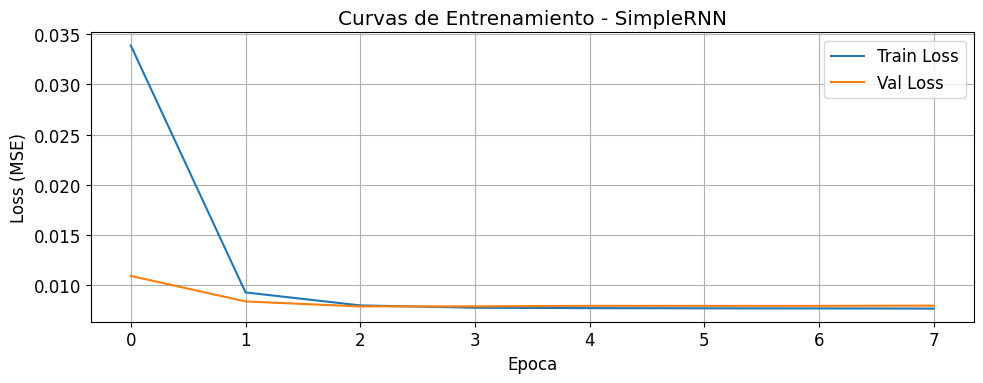


SimpleRNN:
  MAE (test): 0.5026 °C
  Parametros: 1,121


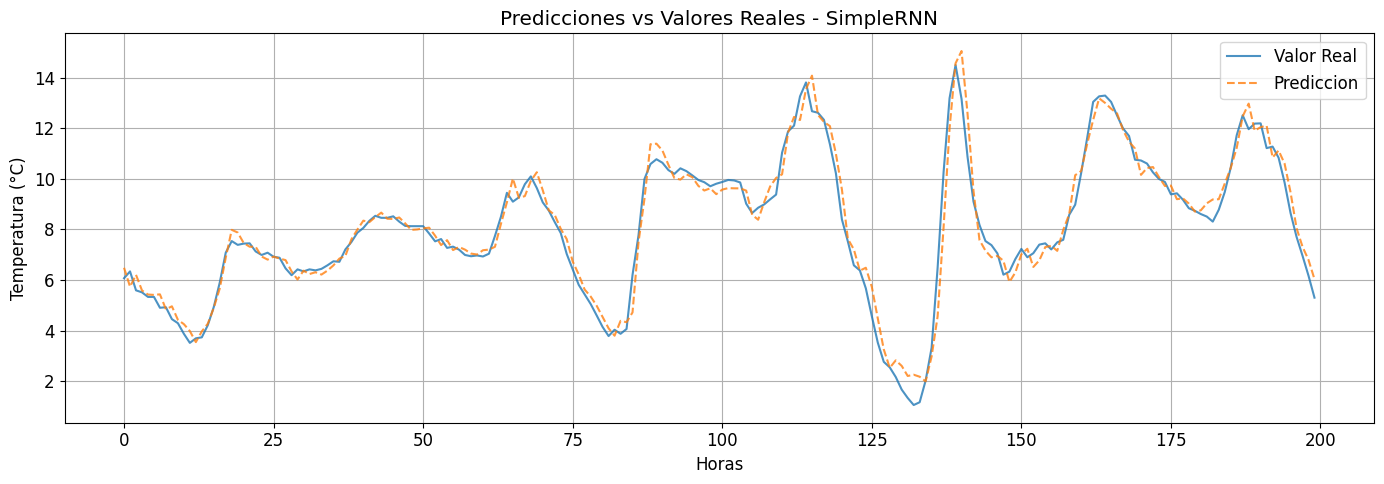

In [43]:
# ============================================================
# Evaluar SimpleRNN
# ============================================================
graficar_historial(hist_rnn, titulo='SimpleRNN')

mae_rnn, pred_rnn, real_rnn = evaluar_modelo(modelo_rnn, X_test, y_test, scaler, nombre='SimpleRNN')
resultados['SimpleRNN'] = {'MAE': mae_rnn, 'Parametros': modelo_rnn.count_params(), 'Tiempo': tiempo_rnn}

graficar_predicciones(real_rnn, pred_rnn, titulo='SimpleRNN', n_puntos=200)

### &#9997;&#65039; Pregunta 4

**¿La RNN supero al modelo denso? ¿Por que las RNN deberian funcionar mejor con datos secuenciales? Explica en terminos de como procesan la informacion temporal.**

### &#9997;&#65039; Tu respuesta:

*Escribe aqui tu respuesta...*

---

### Experimento 4: LSTM (Long Short-Term Memory)

Ahora usamos la **LSTM**, que deberia manejar mejor las dependencias a largo plazo gracias a su mecanismo de puertas y su estado de celda.

In [44]:
# ============================================================
# Modelo: LSTM
# ============================================================
modelo_lstm = models.Sequential([
    # LSTM con 32 unidades
    layers.LSTM(32, input_shape=(TAMANO_VENTANA, 1)),
    layers.Dense(1)
], name='LSTM')

modelo_lstm.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

modelo_lstm.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# ============================================================
# Entrenar LSTM
# ============================================================
print("Entrenando modelo LSTM...")
hist_lstm, tiempo_lstm = entrenar_modelo(modelo_lstm, X_train, y_train, X_val, y_val, epochs=30)
print(f"\nTiempo de entrenamiento: {tiempo_lstm:.1f} segundos")

Entrenando modelo LSTM...
Epoch 1/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0470 - mae: 0.1355 - val_loss: 0.0107 - val_mae: 0.0739
Epoch 2/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0092 - mae: 0.0681 - val_loss: 0.0091 - val_mae: 0.0675
Epoch 3/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0081 - mae: 0.0628 - val_loss: 0.0085 - val_mae: 0.0646
Epoch 4/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0078 - mae: 0.0614 - val_loss: 0.0083 - val_mae: 0.0635
Epoch 5/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0077 - mae: 0.0608 - val_loss: 0.0082 - val_mae: 0.0624
Epoch 6/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0077 - mae: 0.0604 - val_loss: 0.0079 - val_mae: 0.0606
Epoch 7/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0076 - mae: 0.0601 - val_loss: 0.0077 - val_mae: 0.0594
Epoch 8/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0076 - mae: 0.0599 - val_loss: 0.0076 - val_mae: 0.0592
Epoch 9/30
767/767 ━━━━━━━━━━━

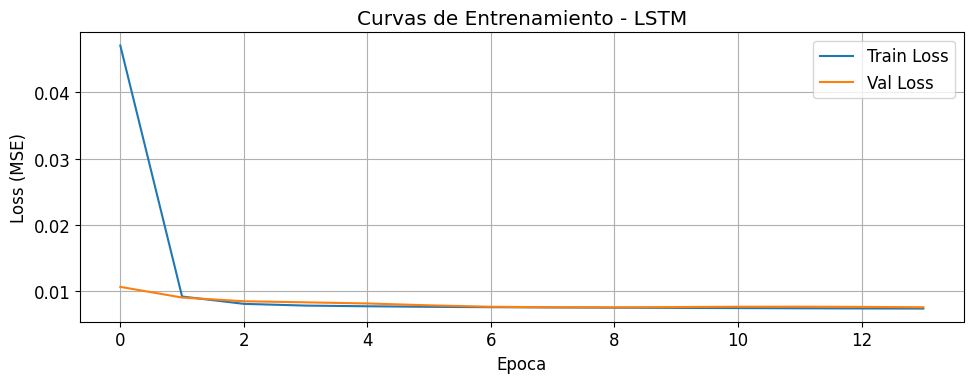


LSTM:
  MAE (test): 0.4859 °C
  Parametros: 4,385


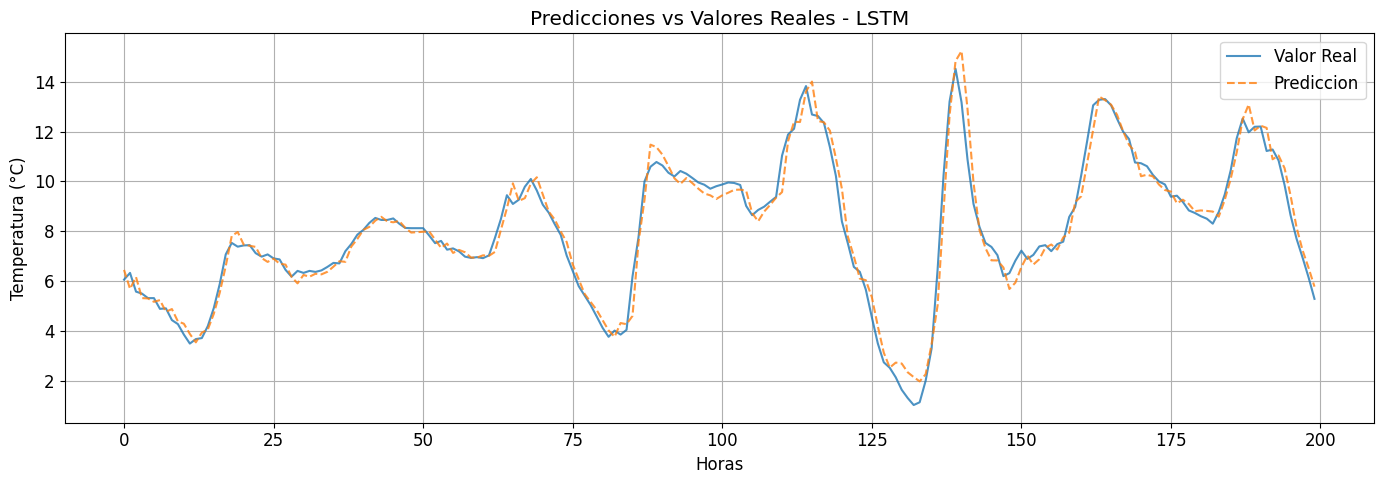

In [46]:
# ============================================================
# Evaluar LSTM
# ============================================================
graficar_historial(hist_lstm, titulo='LSTM')

mae_lstm, pred_lstm, real_lstm = evaluar_modelo(modelo_lstm, X_test, y_test, scaler, nombre='LSTM')
resultados['LSTM'] = {'MAE': mae_lstm, 'Parametros': modelo_lstm.count_params(), 'Tiempo': tiempo_lstm}

graficar_predicciones(real_lstm, pred_lstm, titulo='LSTM', n_puntos=200)

In [47]:
# ============================================================
# Tabla comparativa parcial: DNN vs SimpleRNN vs LSTM
# ============================================================
print("\n" + "="*65)
print("COMPARACION PARCIAL: DNN vs SimpleRNN vs LSTM")
print("="*65)
print(f"{'Modelo':<20} {'MAE (°C)':<12} {'Parametros':<15} {'Tiempo (s)':<12}")
print("-"*65)
for nombre, res in resultados.items():
    print(f"{nombre:<20} {res['MAE']:<12.4f} {res['Parametros']:<15,} {res['Tiempo']:<12.1f}")
print("="*65)


COMPARACION PARCIAL: DNN vs SimpleRNN vs LSTM
Modelo               MAE (°C)     Parametros      Tiempo (s)  
-----------------------------------------------------------------
DNN Baseline         0.4797       3,713           56.5        
SimpleRNN            0.5026       1,121           35.4        
LSTM                 0.4859       4,385           65.7        


### &#9997;&#65039; Pregunta 5

**¿La LSTM supero a la RNN simple? ¿En que tipo de secuencias esperarias que la diferencia entre LSTM y RNN simple sea mayor? (Piensa en la longitud de las dependencias temporales)**

### &#9997;&#65039; Tu respuesta:

*Escribe aqui tu respuesta...*

---

### Experimento 5: GRU (Gated Recurrent Unit)

La GRU es una alternativa mas ligera a la LSTM. Tiene menos parametros porque usa solo 2 puertas en lugar de 3. Veamos como se compara.

In [48]:
# ============================================================
# Modelo: GRU
# ============================================================
modelo_gru = models.Sequential([
    layers.GRU(32, input_shape=(TAMANO_VENTANA, 1)),
    layers.Dense(1)
], name='GRU')

modelo_gru.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

modelo_gru.summary()

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# ============================================================
# Entrenar GRU
# ============================================================
print("Entrenando modelo GRU...")
hist_gru, tiempo_gru = entrenar_modelo(modelo_gru, X_train, y_train, X_val, y_val, epochs=30)
print(f"\nTiempo de entrenamiento: {tiempo_gru:.1f} segundos")

Entrenando modelo GRU...
Epoch 1/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0576 - mae: 0.1391 - val_loss: 0.0108 - val_mae: 0.0718
Epoch 2/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0093 - mae: 0.0670 - val_loss: 0.0086 - val_mae: 0.0642
Epoch 3/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0081 - mae: 0.0623 - val_loss: 0.0084 - val_mae: 0.0634
Epoch 4/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0079 - mae: 0.0614 - val_loss: 0.0083 - val_mae: 0.0631
Epoch 5/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0079 - mae: 0.0611 - val_loss: 0.0082 - val_mae: 0.0629
Epoch 6/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0078 - mae: 0.0610 - val_loss: 0.0082 - val_mae: 0.0628
Epoch 7/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0078 - mae: 0.0608 - val_loss: 0.0082 - val_mae: 0.0626
Epoch 8/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0077 - mae: 0.0606 - val_loss: 0.0081 - val_mae: 0.0622
Epoch 9/30
767/767 ━━━━━━━━━━━━

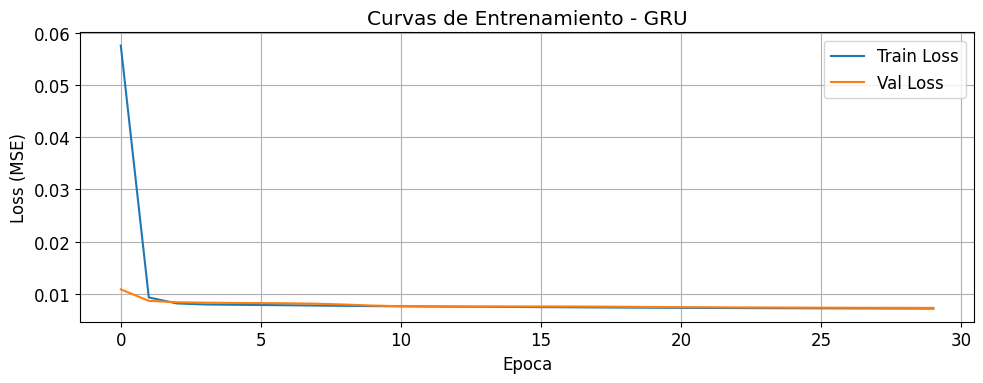


GRU:
  MAE (test): 0.4711 °C
  Parametros: 3,393


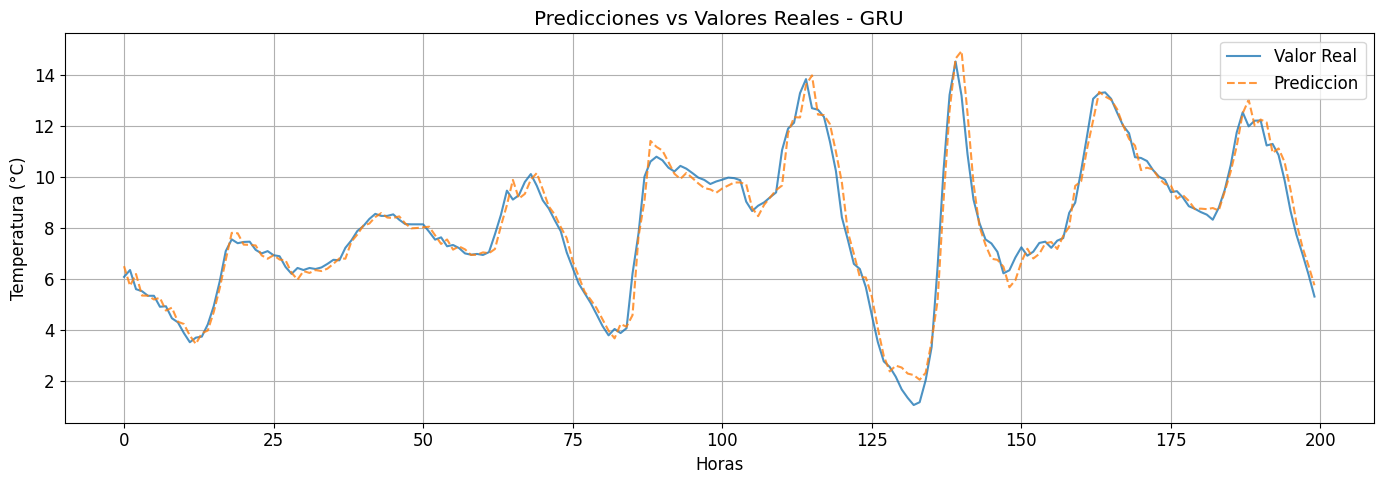

In [50]:
# ============================================================
# Evaluar GRU
# ============================================================
graficar_historial(hist_gru, titulo='GRU')

mae_gru, pred_gru, real_gru = evaluar_modelo(modelo_gru, X_test, y_test, scaler, nombre='GRU')
resultados['GRU'] = {'MAE': mae_gru, 'Parametros': modelo_gru.count_params(), 'Tiempo': tiempo_gru}

graficar_predicciones(real_gru, pred_gru, titulo='GRU', n_puntos=200)

In [51]:
# ============================================================
# Comparacion detallada: LSTM vs GRU
# ============================================================
print("\n" + "="*60)
print("COMPARACION DETALLADA: LSTM vs GRU")
print("="*60)
print(f"{'Metrica':<25} {'LSTM':<15} {'GRU':<15}")
print("-"*60)
print(f"{'MAE (°C)':<25} {resultados['LSTM']['MAE']:<15.4f} {resultados['GRU']['MAE']:<15.4f}")
print(f"{'Parametros':<25} {resultados['LSTM']['Parametros']:<15,} {resultados['GRU']['Parametros']:<15,}")
print(f"{'Tiempo entrenamiento':<25} {resultados['LSTM']['Tiempo']:<15.1f} {resultados['GRU']['Tiempo']:<15.1f}")

ratio_params = modelo_lstm.count_params() / modelo_gru.count_params()
print(f"\nLa LSTM tiene {ratio_params:.2f}x mas parametros que la GRU.")
print("="*60)


COMPARACION DETALLADA: LSTM vs GRU
Metrica                   LSTM            GRU            
------------------------------------------------------------
MAE (°C)                  0.4859          0.4711         
Parametros                4,385           3,393          
Tiempo entrenamiento      65.7            136.9          

La LSTM tiene 1.29x mas parametros que la GRU.


### &#9997;&#65039; Pregunta 6

**¿GRU fue mejor o peor que LSTM? ¿Cuantos parametros tiene cada una? ¿Cuando preferiries GRU sobre LSTM? Considera factores como: tamano del dataset, longitud de las secuencias, tiempo de entrenamiento y recursos disponibles.**

### &#9997;&#65039; Tu respuesta:

*Escribe aqui tu respuesta...*

---

### Experimento 6: Efecto del tamano de la ventana

Un hiperparametro crucial en la prediccion de series temporales es el **tamano de la ventana**: ¿cuantas horas del pasado debemos mirar para predecir la siguiente?

- Ventana muy corta: falta contexto, el modelo no ve patrones a largo plazo.
- Ventana muy larga: mas datos pero tambien mas ruido, y el entrenamiento es mas lento.

Vamos a probar ventanas de: **6, 12, 24, 48 y 168 horas (1 semana)**.

In [52]:
# ============================================================
# Experimento: Diferentes tamanos de ventana
# ============================================================
tamanos_ventana = [6, 12, 24, 48, 168]  # horas
resultados_ventana = {}

for tam in tamanos_ventana:
    print(f"\n{'='*50}")
    print(f"Ventana: {tam} horas ({tam/24:.1f} dias)")
    print(f"{'='*50}")

    # Crear ventanas con el nuevo tamano
    X_tr, y_tr = crear_ventanas(temp_train_norm, tam)
    X_v, y_v = crear_ventanas(temp_val_norm, tam)
    X_te, y_te = crear_ventanas(temp_test_norm, tam)

    print(f"  X_train: {X_tr.shape}, X_val: {X_v.shape}, X_test: {X_te.shape}")

    # Construir modelo LSTM con el tamano de ventana correspondiente
    modelo_v = models.Sequential([
        layers.LSTM(32, input_shape=(tam, 1)),
        layers.Dense(1)
    ], name=f'LSTM_ventana_{tam}')

    modelo_v.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Entrenar
    hist_v, tiempo_v = entrenar_modelo(modelo_v, X_tr, y_tr, X_v, y_v, epochs=30, verbose=0)

    # Evaluar
    mae_v, _, _ = evaluar_modelo(modelo_v, X_te, y_te, scaler, nombre=f'LSTM (ventana={tam}h)')

    resultados_ventana[tam] = {
        'MAE': mae_v,
        'Tiempo': tiempo_v,
        'Epochs': len(hist_v.history['loss'])
    }

    # Liberar memoria
    del modelo_v, X_tr, y_tr, X_v, y_v, X_te, y_te

print("\n\nExperimento de ventanas completado!")


Ventana: 6 horas (0.2 dias)
  X_train: (49058, 6, 1), X_val: (10507, 6, 1), X_test: (10509, 6, 1)

LSTM (ventana=6h):
  MAE (test): 0.5133 °C
  Parametros: 4,385

Ventana: 12 horas (0.5 dias)
  X_train: (49052, 12, 1), X_val: (10501, 12, 1), X_test: (10503, 12, 1)

LSTM (ventana=12h):
  MAE (test): 0.5055 °C
  Parametros: 4,385

Ventana: 24 horas (1.0 dias)
  X_train: (49040, 24, 1), X_val: (10489, 24, 1), X_test: (10491, 24, 1)

LSTM (ventana=24h):
  MAE (test): 0.4792 °C
  Parametros: 4,385

Ventana: 48 horas (2.0 dias)
  X_train: (49016, 48, 1), X_val: (10465, 48, 1), X_test: (10467, 48, 1)

LSTM (ventana=48h):
  MAE (test): 0.4681 °C
  Parametros: 4,385

Ventana: 168 horas (7.0 dias)
  X_train: (48896, 168, 1), X_val: (10345, 168, 1), X_test: (10347, 168, 1)

LSTM (ventana=168h):
  MAE (test): 0.4726 °C
  Parametros: 4,385


Experimento de ventanas completado!


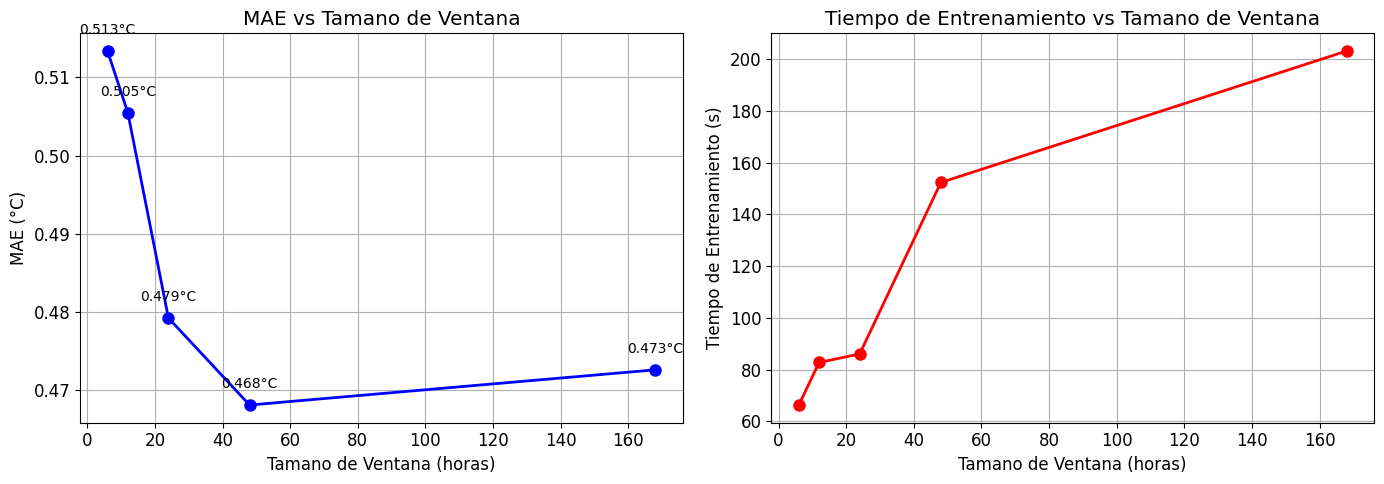


Ventana (h)     MAE (°C)     Tiempo (s)   Epochs    
--------------------------------------------------
6               0.5133       66.3         16        
12              0.5055       82.8         20        
24              0.4792       86.1         19        
48              0.4681       152.3        30        
168             0.4726       203.1        30        


In [53]:
# ============================================================
# Graficar MAE vs Tamano de Ventana
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tamanos = list(resultados_ventana.keys())
maes = [resultados_ventana[t]['MAE'] for t in tamanos]
tiempos = [resultados_ventana[t]['Tiempo'] for t in tamanos]

# MAE vs Tamano de ventana
axes[0].plot(tamanos, maes, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Tamano de Ventana (horas)')
axes[0].set_ylabel('MAE (°C)')
axes[0].set_title('MAE vs Tamano de Ventana')
for i, (t, m) in enumerate(zip(tamanos, maes)):
    axes[0].annotate(f'{m:.3f}°C', (t, m), textcoords='offset points',
                     xytext=(0, 12), ha='center', fontsize=10)

# Tiempo vs Tamano de ventana
axes[1].plot(tamanos, tiempos, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Tamano de Ventana (horas)')
axes[1].set_ylabel('Tiempo de Entrenamiento (s)')
axes[1].set_title('Tiempo de Entrenamiento vs Tamano de Ventana')

plt.tight_layout()
plt.show()

# Tabla resumen
print(f"\n{'Ventana (h)':<15} {'MAE (°C)':<12} {'Tiempo (s)':<12} {'Epochs':<10}")
print("-"*50)
for t in tamanos:
    r = resultados_ventana[t]
    print(f"{t:<15} {r['MAE']:<12.4f} {r['Tiempo']:<12.1f} {r['Epochs']:<10}")

### &#9997;&#65039; Pregunta 7

**¿Cual tamano de ventana dio los mejores resultados? ¿Hay un punto donde mas datos del pasado ya no ayudan (o incluso empeoran)? ¿Por que crees que ocurre esto? Considera la relacion entre el tamano de la ventana y los patrones naturales de la temperatura (ciclo diario, semanal, etc.).**

### &#9997;&#65039; Tu respuesta:

*Escribe aqui tu respuesta...*

---

### Experimento 7: LSTM Apilada y Bidirectional

Ahora exploraremos dos arquitecturas mas avanzadas:

1. **LSTM Apilada (Stacked LSTM):** Dos capas LSTM una encima de otra. La primera debe usar `return_sequences=True` para pasar la secuencia completa a la segunda capa.

2. **Bidirectional LSTM:** Procesa la secuencia en ambas direcciones (pasado -> futuro y futuro -> pasado).

In [54]:
# ============================================================
# Modelo: LSTM Apilada (Stacked LSTM)
# ============================================================
# La primera LSTM debe usar return_sequences=True
# para que pase la secuencia COMPLETA a la siguiente capa LSTM
# (no solo el ultimo estado oculto)

modelo_stacked = models.Sequential([
    layers.LSTM(32, return_sequences=True, input_shape=(TAMANO_VENTANA, 1)),  # Salida: (batch, 24, 32)
    layers.LSTM(16),  # Salida: (batch, 16) - solo ultimo estado
    layers.Dense(1)
], name='Stacked_LSTM')

modelo_stacked.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Arquitectura: LSTM(32, return_sequences=True) -> LSTM(16) -> Dense(1)")
modelo_stacked.summary()

Arquitectura: LSTM(32, return_sequences=True) -> LSTM(16) -> Dense(1)


Model: "Stacked_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 24, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,505 (29.32 KB)

 Trainable params: 7,505 (29.32 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# ============================================================
# Entrenar LSTM Apilada
# ============================================================
print("Entrenando LSTM Apilada...")
hist_stacked, tiempo_stacked = entrenar_modelo(
    modelo_stacked, X_train, y_train, X_val, y_val, epochs=30
)
print(f"\nTiempo de entrenamiento: {tiempo_stacked:.1f} segundos")

Entrenando LSTM Apilada...
Epoch 1/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0741 - mae: 0.1731 - val_loss: 0.0125 - val_mae: 0.0789
Epoch 2/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0097 - mae: 0.0705 - val_loss: 0.0090 - val_mae: 0.0668
Epoch 3/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0082 - mae: 0.0635 - val_loss: 0.0081 - val_mae: 0.0617
Epoch 4/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0080 - mae: 0.0622 - val_loss: 0.0083 - val_mae: 0.0629
Epoch 5/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0079 - mae: 0.0616 - val_loss: 0.0084 - val_mae: 0.0634
Epoch 6/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0078 - mae: 0.0612 - val_loss: 0.0084 - val_mae: 0.0633
Epoch 7/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0078 - mae: 0.0609 - val_loss: 0.0084 - val_mae: 0.0632
Epoch 8/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0077 - mae: 0.0606 - val_loss: 0.0083 - val_mae: 0.0629

Tiempo de entrenamiento: 54.

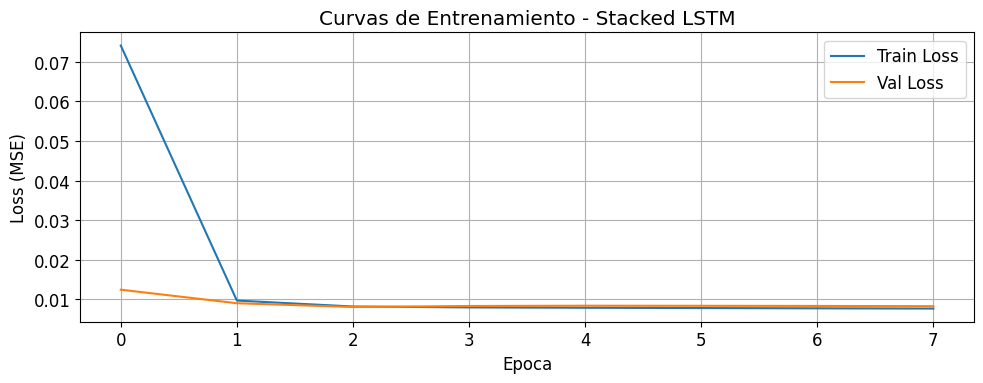


Stacked LSTM:
  MAE (test): 0.5071 °C
  Parametros: 7,505


In [56]:
# ============================================================
# Evaluar LSTM Apilada
# ============================================================
graficar_historial(hist_stacked, titulo='Stacked LSTM')

mae_stacked, pred_stacked, real_stacked = evaluar_modelo(
    modelo_stacked, X_test, y_test, scaler, nombre='Stacked LSTM'
)
resultados['Stacked LSTM'] = {
    'MAE': mae_stacked,
    'Parametros': modelo_stacked.count_params(),
    'Tiempo': tiempo_stacked
}

In [57]:
# ============================================================
# Modelo: Bidirectional LSTM
# ============================================================
modelo_bidir = models.Sequential([
    layers.Bidirectional(
        layers.LSTM(32),
        input_shape=(TAMANO_VENTANA, 1)
    ),  # Salida: (batch, 64) porque concatena forward (32) + backward (32)
    layers.Dense(1)
], name='Bidirectional_LSTM')

modelo_bidir.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Arquitectura: Bidirectional(LSTM(32)) -> Dense(1)")
print("Nota: La salida de la capa Bidirectional es 64 (32 forward + 32 backward)")
modelo_bidir.summary()

Arquitectura: Bidirectional(LSTM(32)) -> Dense(1)
Nota: La salida de la capa Bidirectional es 64 (32 forward + 32 backward)


Model: "Bidirectional_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 64)             │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,769 (34.25 KB)

 Trainable params: 8,769 (34.25 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
# ============================================================
# Entrenar Bidirectional LSTM
# ============================================================
print("Entrenando Bidirectional LSTM...")
hist_bidir, tiempo_bidir = entrenar_modelo(
    modelo_bidir, X_train, y_train, X_val, y_val, epochs=30
)
print(f"\nTiempo de entrenamiento: {tiempo_bidir:.1f} segundos")

Entrenando Bidirectional LSTM...
Epoch 1/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0538 - mae: 0.1452 - val_loss: 0.0112 - val_mae: 0.0756
Epoch 2/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0091 - mae: 0.0675 - val_loss: 0.0086 - val_mae: 0.0648
Epoch 3/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0079 - mae: 0.0618 - val_loss: 0.0080 - val_mae: 0.0619
Epoch 4/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0078 - mae: 0.0609 - val_loss: 0.0078 - val_mae: 0.0601
Epoch 5/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0077 - mae: 0.0606 - val_loss: 0.0077 - val_mae: 0.0596
Epoch 6/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0077 - mae: 0.0603 - val_loss: 0.0076 - val_mae: 0.0594
Epoch 7/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0076 - mae: 0.0600 - val_loss: 0.0076 - val_mae: 0.0593
Epoch 8/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0075 - mae: 0.0597 - val_loss: 0.0075 - val_mae: 0.0592
Epoch 9/30
767/767 ━━

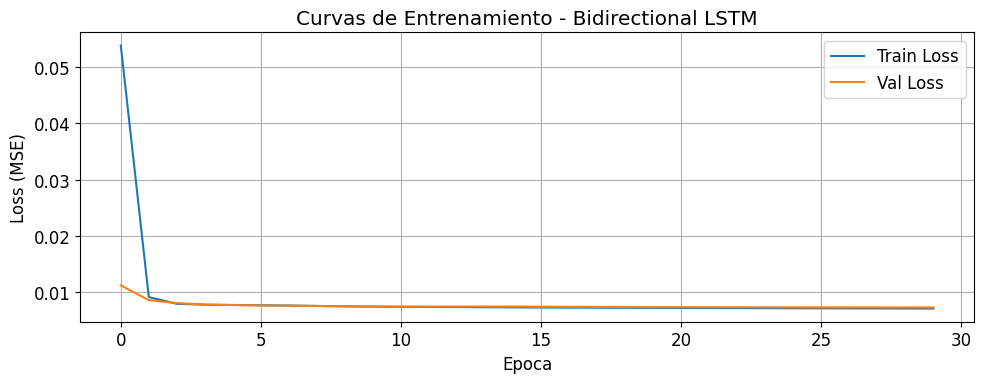


Bidirectional LSTM:
  MAE (test): 0.4744 °C
  Parametros: 8,769


In [59]:
# ============================================================
# Evaluar Bidirectional LSTM
# ============================================================
graficar_historial(hist_bidir, titulo='Bidirectional LSTM')

mae_bidir, pred_bidir, real_bidir = evaluar_modelo(
    modelo_bidir, X_test, y_test, scaler, nombre='Bidirectional LSTM'
)
resultados['Bidirectional LSTM'] = {
    'MAE': mae_bidir,
    'Parametros': modelo_bidir.count_params(),
    'Tiempo': tiempo_bidir
}

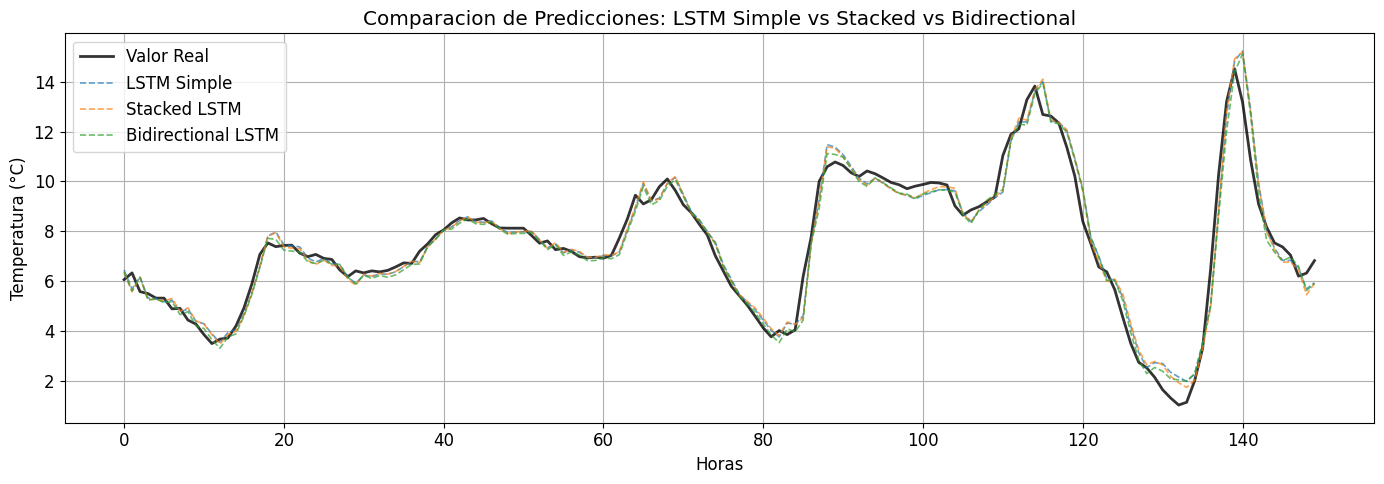

In [60]:
# ============================================================
# Comparacion visual: LSTM Simple vs Stacked vs Bidirectional
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))

n_pts = 150
ax.plot(real_lstm[:n_pts], label='Valor Real', linewidth=2, color='black', alpha=0.8)
ax.plot(pred_lstm[:n_pts], label='LSTM Simple', linewidth=1.2, alpha=0.7, linestyle='--')
ax.plot(pred_stacked[:n_pts], label='Stacked LSTM', linewidth=1.2, alpha=0.7, linestyle='--')
ax.plot(pred_bidir[:n_pts], label='Bidirectional LSTM', linewidth=1.2, alpha=0.7, linestyle='--')

ax.set_xlabel('Horas')
ax.set_ylabel('Temperatura (°C)')
ax.set_title('Comparacion de Predicciones: LSTM Simple vs Stacked vs Bidirectional')
ax.legend()
plt.tight_layout()
plt.show()

### &#9997;&#65039; Pregunta 8

**¿Las capas apiladas (Stacked LSTM) mejoraron el resultado respecto a la LSTM simple? ¿Y la LSTM bidireccional? ¿Tiene sentido usar una RNN bidireccional para prediccion de series temporales? Justifica tu respuesta pensando en que informacion tiene disponible el modelo en el momento de hacer la prediccion.**

### &#9997;&#65039; Tu respuesta:

*Escribe aqui tu respuesta...*

---

### Experimento 8: Prediccion Multivariable

Hasta ahora solo usamos la **temperatura** como unica variable de entrada (prediccion univariable). Pero el dataset Jena Climate tiene muchas mas variables meteorologicas que podrian ayudar a predecir la temperatura.

En este experimento, usaremos **multiples features** como entrada:
- Temperatura pasada
- Presion atmosferica
- Humedad relativa
- Velocidad del viento
- Y otras variables

El objetivo sigue siendo predecir la **temperatura** de la proxima hora.

In [61]:
# ============================================================
# Preparar datos multivariable
# ============================================================
# Seleccionar las columnas numericas (excluir la columna de fecha)
columnas_features = [col for col in df_hourly.columns if col != 'Date Time']

print("Features disponibles:")
for i, col in enumerate(columnas_features):
    print(f"  {i}: {col}")

# Asegurarnos de que la temperatura sea la primera columna (para la funcion crear_ventanas)
# Verificar que 'T (degC)' esta en las columnas
idx_temp = columnas_features.index('T (degC)')
print(f"\nIndice de temperatura: {idx_temp}")

# Reorganizar para que temperatura sea la primera columna
columnas_ordenadas = ['T (degC)'] + [col for col in columnas_features if col != 'T (degC)']

datos_multi = df_hourly[columnas_ordenadas].values.astype(np.float32)
print(f"\nForma de datos multivariable: {datos_multi.shape}")
print(f"Numero de features: {datos_multi.shape[1]}")

Features disponibles:
  0: p (mbar)
  1: T (degC)
  2: Tpot (K)
  3: Tdew (degC)
  4: rh (%)
  5: VPmax (mbar)
  6: VPact (mbar)
  7: VPdef (mbar)
  8: sh (g/kg)
  9: H2OC (mmol/mol)
  10: rho (g/m**3)
  11: wv (m/s)
  12: max. wv (m/s)
  13: wd (deg)

Indice de temperatura: 1

Forma de datos multivariable: (70092, 14)
Numero de features: 14


In [62]:
# ============================================================
# Split cronologico de datos multivariable
# ============================================================
datos_train_multi = datos_multi[:n_train]
datos_val_multi = datos_multi[n_train:n_train + n_val]
datos_test_multi = datos_multi[n_train + n_val:]

print(f"Train: {datos_train_multi.shape}")
print(f"Val:   {datos_val_multi.shape}")
print(f"Test:  {datos_test_multi.shape}")

Train: (49064, 14)
Val:   (10513, 14)
Test:  (10515, 14)


In [63]:
# ============================================================
# Normalizar cada feature con StandardScaler (ajustar solo en train)
# ============================================================
scaler_multi = StandardScaler()

datos_train_norm_multi = scaler_multi.fit_transform(datos_train_multi)
datos_val_norm_multi = scaler_multi.transform(datos_val_multi)
datos_test_norm_multi = scaler_multi.transform(datos_test_multi)

print("Normalizacion multivariable completada.")
print(f"Medias (train): {scaler_multi.mean_[:5].round(2)}... (mostrando primeras 5)")
print(f"Stds (train):   {scaler_multi.scale_[:5].round(2)}... (mostrando primeras 5)")

Normalizacion multivariable completada.
Medias (train): [  9.11 988.66 283.19   4.6   75.9 ]... (mostrando primeras 5)
Stds (train):   [ 8.66  8.3   8.72  6.97 16.56]... (mostrando primeras 5)


In [64]:
# ============================================================
# Crear ventanas deslizantes multivariable
# ============================================================
# Ahora X tendra forma (muestras, 24, num_features) en lugar de (muestras, 24, 1)
# y seguimos prediciendo solo la temperatura (primera columna)

X_train_multi, y_train_multi = crear_ventanas(datos_train_norm_multi, TAMANO_VENTANA)
X_val_multi, y_val_multi = crear_ventanas(datos_val_norm_multi, TAMANO_VENTANA)
X_test_multi, y_test_multi = crear_ventanas(datos_test_norm_multi, TAMANO_VENTANA)

num_features = X_train_multi.shape[2]

print(f"Datos multivariable con ventana de {TAMANO_VENTANA} horas:")
print(f"  X_train: {X_train_multi.shape}  (muestras, pasos, features)")
print(f"  X_val:   {X_val_multi.shape}")
print(f"  X_test:  {X_test_multi.shape}")
print(f"\nNumero de features: {num_features}")
print(f"Features: {columnas_ordenadas[:5]}... (y {num_features-5} mas)")

Datos multivariable con ventana de 24 horas:
  X_train: (49040, 24, 14)  (muestras, pasos, features)
  X_val:   (10489, 24, 14)
  X_test:  (10491, 24, 14)

Numero de features: 14
Features: ['T (degC)', 'p (mbar)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)']... (y 9 mas)


In [65]:
# ============================================================
# Modelo: LSTM Multivariable
# ============================================================
modelo_multi = models.Sequential([
    layers.LSTM(32, input_shape=(TAMANO_VENTANA, num_features)),
    layers.Dense(1)
], name='LSTM_Multivariable')

modelo_multi.compile(optimizer='adam', loss='mse', metrics=['mae'])

print(f"Modelo LSTM con {num_features} features de entrada:")
modelo_multi.summary()

Modelo LSTM con 14 features de entrada:


Model: "LSTM_Multivariable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 32)             │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,049 (23.63 KB)

 Trainable params: 6,049 (23.63 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
# ============================================================
# Entrenar LSTM Multivariable
# ============================================================
print("Entrenando LSTM Multivariable...")
hist_multi, tiempo_multi = entrenar_modelo(
    modelo_multi, X_train_multi, y_train_multi,
    X_val_multi, y_val_multi, epochs=30
)
print(f"\nTiempo de entrenamiento: {tiempo_multi:.1f} segundos")

Entrenando LSTM Multivariable...
Epoch 1/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0330 - mae: 0.1129 - val_loss: 0.0108 - val_mae: 0.0715
Epoch 2/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0084 - mae: 0.0648 - val_loss: 0.0090 - val_mae: 0.0662
Epoch 3/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0075 - mae: 0.0607 - val_loss: 0.0089 - val_mae: 0.0645
Epoch 4/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0073 - mae: 0.0593 - val_loss: 0.0085 - val_mae: 0.0621
Epoch 5/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0071 - mae: 0.0583 - val_loss: 0.0079 - val_mae: 0.0595
Epoch 6/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0070 - mae: 0.0576 - val_loss: 0.0080 - val_mae: 0.0585
Epoch 7/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0069 - mae: 0.0572 - val_loss: 0.0079 - val_mae: 0.0580
Epoch 8/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0068 - mae: 0.0568 - val_loss: 0.0070 - val_mae: 0.0574
Epoch 9/30
767/767 ━━━━

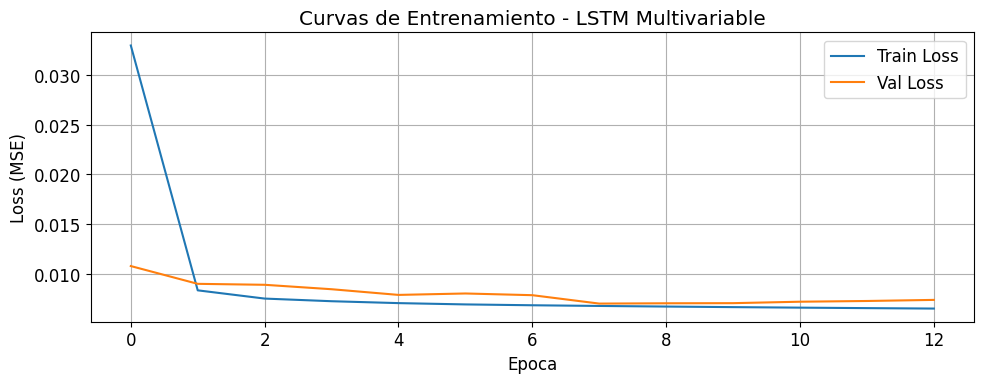


LSTM Multivariable:
  MAE (test): 0.4722 °C
  Parametros: 6,049


In [67]:
# ============================================================
# Evaluar LSTM Multivariable
# ============================================================
graficar_historial(hist_multi, titulo='LSTM Multivariable')

# Para desnormalizar la temperatura, necesitamos los parametros del scaler
# para la primera columna (temperatura)
scaler_temp_multi = StandardScaler()
scaler_temp_multi.mean_ = scaler_multi.mean_[:1]
scaler_temp_multi.scale_ = scaler_multi.scale_[:1]
scaler_temp_multi.var_ = scaler_multi.var_[:1]
scaler_temp_multi.n_features_in_ = 1

mae_multi, pred_multi, real_multi = evaluar_modelo(
    modelo_multi, X_test_multi, y_test_multi,
    scaler_temp_multi, nombre='LSTM Multivariable'
)
resultados['LSTM Multivariable'] = {
    'MAE': mae_multi,
    'Parametros': modelo_multi.count_params(),
    'Tiempo': tiempo_multi
}

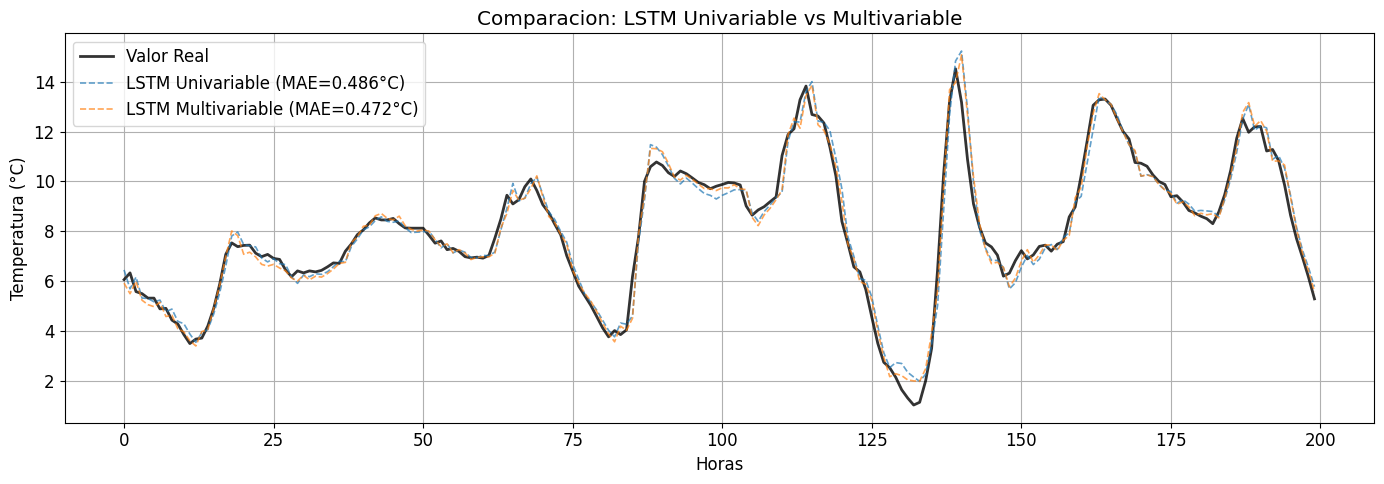

In [68]:
# ============================================================
# Comparacion visual: Univariable vs Multivariable
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))

n_pts = 200
ax.plot(real_lstm[:n_pts], label='Valor Real', linewidth=2, color='black', alpha=0.8)
ax.plot(pred_lstm[:n_pts], label=f'LSTM Univariable (MAE={resultados["LSTM"]["MAE"]:.3f}°C)',
        linewidth=1.2, alpha=0.7, linestyle='--')
ax.plot(pred_multi[:n_pts], label=f'LSTM Multivariable (MAE={mae_multi:.3f}°C)',
        linewidth=1.2, alpha=0.7, linestyle='--')

ax.set_xlabel('Horas')
ax.set_ylabel('Temperatura (°C)')
ax.set_title('Comparacion: LSTM Univariable vs Multivariable')
ax.legend()
plt.tight_layout()
plt.show()

### &#9997;&#65039; Pregunta 9

**¿Agregar mas variables meteorologicas mejoro la prediccion de temperatura? ¿Que variables crees que son mas utiles para predecir la temperatura? ¿Siempre es bueno agregar mas features? ¿Que riesgos hay?**

### &#9997;&#65039; Tu respuesta:

*Escribe aqui tu respuesta...*

---

## 5. Sintesis y Comparacion Final

Ahora vamos a reunir todos los resultados para tener una vision completa de lo aprendido.

In [69]:
# ============================================================
# Tabla comparativa FINAL de todos los modelos
# ============================================================
print("\n" + "="*75)
print("TABLA COMPARATIVA FINAL - TODOS LOS MODELOS")
print("="*75)
print(f"{'Modelo':<25} {'MAE (°C)':<12} {'Parametros':<15} {'Tiempo (s)':<12}")
print("-"*75)

# Ordenar por MAE
resultados_ordenados = sorted(resultados.items(), key=lambda x: x[1]['MAE'])

for nombre, res in resultados_ordenados:
    print(f"{nombre:<25} {res['MAE']:<12.4f} {res['Parametros']:<15,} {res['Tiempo']:<12.1f}")

print("="*75)

mejor = resultados_ordenados[0]
peor = resultados_ordenados[-1]
print(f"\nMejor modelo:  {mejor[0]} (MAE = {mejor[1]['MAE']:.4f} °C)")
print(f"Peor modelo:   {peor[0]} (MAE = {peor[1]['MAE']:.4f} °C)")
print(f"Mejora del mejor vs peor: {(1 - mejor[1]['MAE']/peor[1]['MAE'])*100:.1f}%")


TABLA COMPARATIVA FINAL - TODOS LOS MODELOS
Modelo                    MAE (°C)     Parametros      Tiempo (s)  
---------------------------------------------------------------------------
GRU                       0.4711       3,393           136.9       
LSTM Multivariable        0.4722       6,049           62.4        
Bidirectional LSTM        0.4744       8,769           193.2       
DNN Baseline              0.4797       3,713           56.5        
LSTM                      0.4859       4,385           65.7        
SimpleRNN                 0.5026       1,121           35.4        
Stacked LSTM              0.5071       7,505           54.7        

Mejor modelo:  GRU (MAE = 0.4711 °C)
Peor modelo:   Stacked LSTM (MAE = 0.5071 °C)
Mejora del mejor vs peor: 7.1%


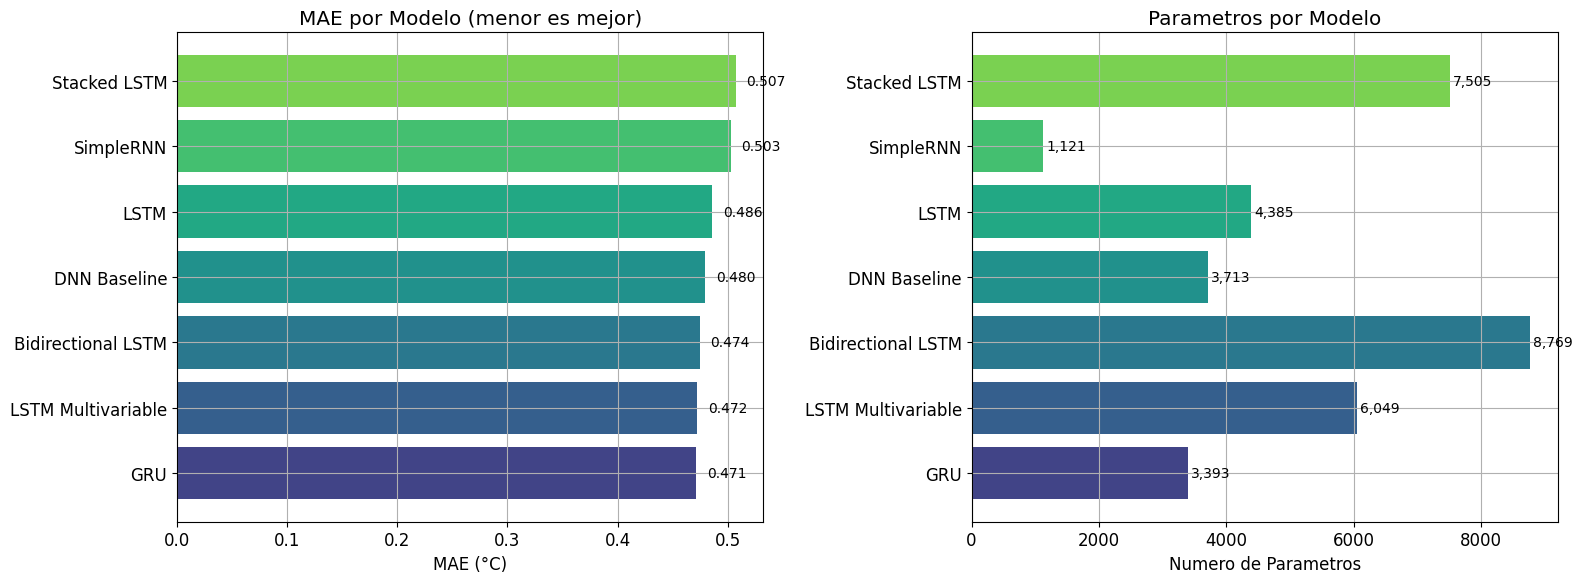

In [70]:
# ============================================================
# Grafico de barras comparativo
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

nombres = [r[0] for r in resultados_ordenados]
maes_final = [r[1]['MAE'] for r in resultados_ordenados]
params_final = [r[1]['Parametros'] for r in resultados_ordenados]

# MAE por modelo
colores = plt.cm.viridis(np.linspace(0.2, 0.8, len(nombres)))
bars = axes[0].barh(nombres, maes_final, color=colores)
axes[0].set_xlabel('MAE (°C)')
axes[0].set_title('MAE por Modelo (menor es mejor)')
for bar, mae_val in zip(bars, maes_final):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{mae_val:.3f}', va='center', fontsize=10)

# Parametros por modelo
bars2 = axes[1].barh(nombres, params_final, color=colores)
axes[1].set_xlabel('Numero de Parametros')
axes[1].set_title('Parametros por Modelo')
for bar, p in zip(bars2, params_final):
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                f'{p:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### &#9997;&#65039; Pregunta 10 - Sintesis

**Crea una tabla comparativa en tu respuesta con TODOS los modelos probados en esta guia (DNN, SimpleRNN, LSTM, GRU, Stacked LSTM, Bidirectional LSTM, LSTM Multivariable). Incluye: nombre del modelo, MAE, numero de parametros, y una breve observacion sobre cada uno.**

### &#9997;&#65039; Tu respuesta:

*Escribe aqui tu respuesta...*

### &#9997;&#65039; Pregunta 11

**¿Para que otro tipo de datos secuenciales (NO series temporales) podrias usar RNN/LSTM? Menciona al menos 3 aplicaciones diferentes y explica brevemente como se aplicaria la RNN en cada caso.**

### &#9997;&#65039; Tu respuesta:

*Escribe aqui tu respuesta...*

### &#9997;&#65039; Pregunta 12

**¿Que crees que viene despues en el curso? Si las LSTM son buenas para secuencias, ¿como las aplicarias al procesamiento de texto? ¿Que necesitarias para convertir palabras en numeros que la LSTM pueda procesar?**

### &#9997;&#65039; Tu respuesta:

*Escribe aqui tu respuesta...*

---

## 6. Reto Extra: Prediccion a 24 horas

Hasta ahora predijimos la temperatura **1 hora** adelante. Pero en aplicaciones reales, es mucho mas util predecir con mas anticipacion.

**Reto:** Predecir la temperatura **24 horas** en el futuro usando la mejor configuracion encontrada.

**Objetivo:** Obtener un MAE menor a **3°C** para la prediccion a 24 horas.

In [71]:
# ============================================================
# RETO: Prediccion a 24 horas adelante
# ============================================================
HORIZONTE = 24  # Predecir 24 horas en el futuro

print(f"Reto: Predecir la temperatura {HORIZONTE} horas en el futuro")
print(f"Ventana de entrada: {TAMANO_VENTANA} horas")
print(f"Horizonte de prediccion: {HORIZONTE} horas")

# Crear ventanas con horizonte de 24 horas
X_train_reto, y_train_reto = crear_ventanas(temp_train_norm, TAMANO_VENTANA, horizonte=HORIZONTE)
X_val_reto, y_val_reto = crear_ventanas(temp_val_norm, TAMANO_VENTANA, horizonte=HORIZONTE)
X_test_reto, y_test_reto = crear_ventanas(temp_test_norm, TAMANO_VENTANA, horizonte=HORIZONTE)

print(f"\nFormas de los datos (horizonte={HORIZONTE}h):")
print(f"  X_train: {X_train_reto.shape}  y_train: {y_train_reto.shape}")
print(f"  X_val:   {X_val_reto.shape}  y_val:   {y_val_reto.shape}")
print(f"  X_test:  {X_test_reto.shape}  y_test:  {y_test_reto.shape}")

Reto: Predecir la temperatura 24 horas en el futuro
Ventana de entrada: 24 horas
Horizonte de prediccion: 24 horas

Formas de los datos (horizonte=24h):
  X_train: (49017, 24, 1)  y_train: (49017,)
  X_val:   (10466, 24, 1)  y_val:   (10466,)
  X_test:  (10468, 24, 1)  y_test:  (10468,)


In [72]:
# ============================================================
# Modelo para el reto: LSTM con mas capacidad
# ============================================================
# Usamos una LSTM un poco mas grande ya que la tarea es mas dificil

modelo_reto = models.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(TAMANO_VENTANA, 1)),
    layers.LSTM(32),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
], name='LSTM_Reto_24h')

modelo_reto.compile(optimizer='adam', loss='mse', metrics=['mae'])

print(f"Modelo para prediccion a {HORIZONTE}h:")
modelo_reto.summary()

Modelo para prediccion a 24h:


Model: "LSTM_Reto_24h"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
# ============================================================
# Entrenar modelo del reto
# ============================================================
print(f"Entrenando modelo para prediccion a {HORIZONTE} horas...")
hist_reto, tiempo_reto = entrenar_modelo(
    modelo_reto, X_train_reto, y_train_reto,
    X_val_reto, y_val_reto, epochs=50
)
print(f"\nTiempo de entrenamiento: {tiempo_reto:.1f} segundos")

Entrenando modelo para prediccion a 24 horas...
Epoch 1/50
766/766 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.1758 - mae: 0.3248 - val_loss: 0.1512 - val_mae: 0.3005
Epoch 2/50
766/766 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.1466 - mae: 0.2992 - val_loss: 0.1475 - val_mae: 0.2972
Epoch 3/50
766/766 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.1437 - mae: 0.2962 - val_loss: 0.1454 - val_mae: 0.2953
Epoch 4/50
766/766 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.1419 - mae: 0.2942 - val_loss: 0.1439 - val_mae: 0.2942
Epoch 5/50
766/766 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.1406 - mae: 0.2928 - val_loss: 0.1444 - val_mae: 0.2945
Epoch 6/50
766/766 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.1398 - mae: 0.2920 - val_loss: 0.1451 - val_mae: 0.2945
Epoch 7/50
766/766 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.1386 - mae: 0.2906 - val_loss: 0.1432 - val_mae: 0.2927
Epoch 8/50
766/766 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.1379 - mae: 0.2898 - val_loss: 0.1415 - val_mae: 0.2911
Epoch 9

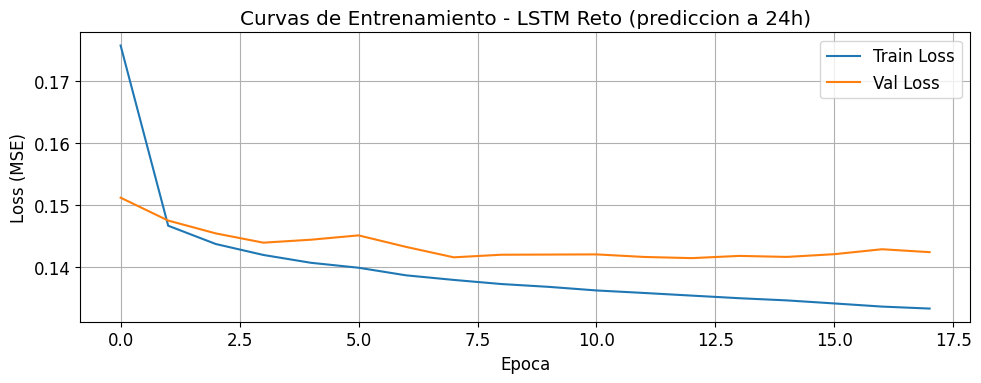


LSTM Reto (24h adelante):
  MAE (test): 2.4535 °C
  Parametros: 29,857

COMPARACION: 1 hora vs 24 horas adelante
MAE prediccion a 1h:   0.4859 °C
MAE prediccion a 24h:  2.4535 °C
Aumento del error:     404.9%

Objetivo del reto: MAE < 3.0 °C
RETO SUPERADO! MAE = 2.4535 °C < 3.0 °C


In [74]:
# ============================================================
# Evaluar modelo del reto
# ============================================================
graficar_historial(hist_reto, titulo=f'LSTM Reto (prediccion a {HORIZONTE}h)')

mae_reto, pred_reto, real_reto = evaluar_modelo(
    modelo_reto, X_test_reto, y_test_reto,
    scaler, nombre=f'LSTM Reto ({HORIZONTE}h adelante)'
)

# Comparar con prediccion a 1 hora
print(f"\n{'='*50}")
print(f"COMPARACION: 1 hora vs {HORIZONTE} horas adelante")
print(f"{'='*50}")
print(f"MAE prediccion a 1h:   {resultados['LSTM']['MAE']:.4f} °C")
print(f"MAE prediccion a {HORIZONTE}h:  {mae_reto:.4f} °C")
print(f"Aumento del error:     {((mae_reto / resultados['LSTM']['MAE']) - 1) * 100:.1f}%")
print(f"\nObjetivo del reto: MAE < 3.0 °C")
if mae_reto < 3.0:
    print(f"RETO SUPERADO! MAE = {mae_reto:.4f} °C < 3.0 °C")
else:
    print(f"Reto no superado. MAE = {mae_reto:.4f} °C >= 3.0 °C")
    print("Intenta ajustar la arquitectura, el tamano de ventana o las features de entrada.")

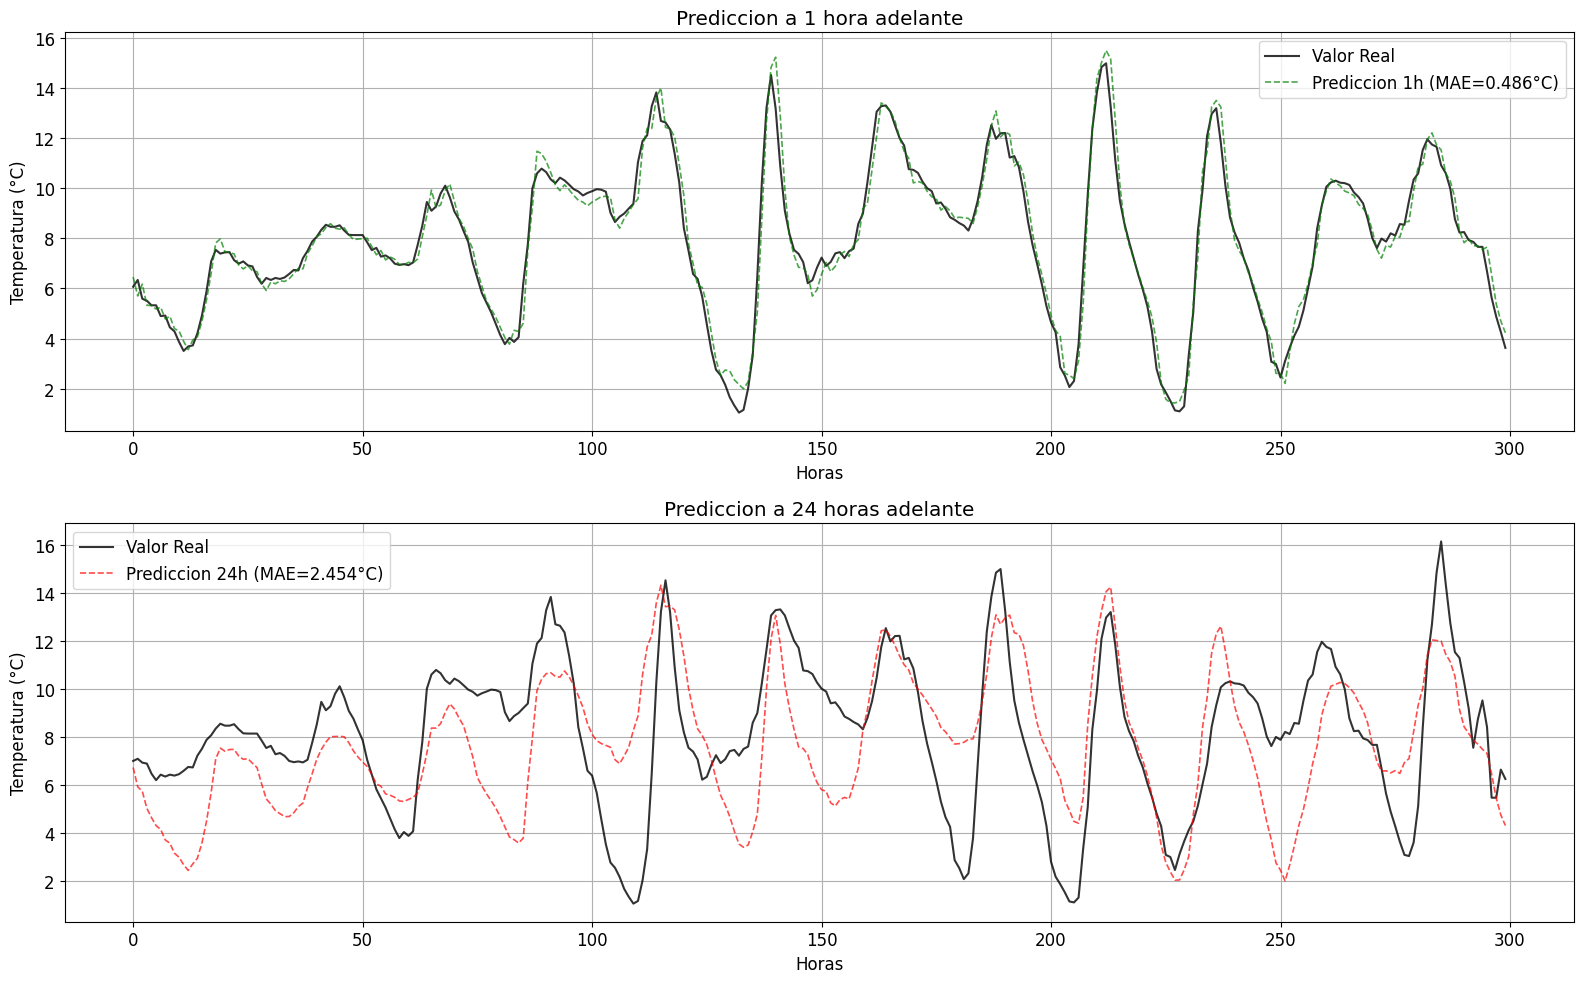

Observa como las predicciones a 24 horas son menos precisas pero aun
capturan la tendencia general de la temperatura.


In [75]:
# ============================================================
# Graficar predicciones del reto
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

n_pts = 300

# Predicciones a 1 hora
axes[0].plot(real_lstm[:n_pts], label='Valor Real', linewidth=1.5, color='black', alpha=0.8)
axes[0].plot(pred_lstm[:n_pts], label=f'Prediccion 1h (MAE={resultados["LSTM"]["MAE"]:.3f}°C)',
             linewidth=1.2, alpha=0.7, linestyle='--', color='green')
axes[0].set_xlabel('Horas')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].set_title('Prediccion a 1 hora adelante')
axes[0].legend()

# Predicciones a 24 horas
axes[1].plot(real_reto[:n_pts], label='Valor Real', linewidth=1.5, color='black', alpha=0.8)
axes[1].plot(pred_reto[:n_pts], label=f'Prediccion {HORIZONTE}h (MAE={mae_reto:.3f}°C)',
             linewidth=1.2, alpha=0.7, linestyle='--', color='red')
axes[1].set_xlabel('Horas')
axes[1].set_ylabel('Temperatura (°C)')
axes[1].set_title(f'Prediccion a {HORIZONTE} horas adelante')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Observa como las predicciones a 24 horas son menos precisas pero aun")
print("capturan la tendencia general de la temperatura.")

---

## 7. Referencias

### Articulos fundamentales
- **Hochreiter, S. & Schmidhuber, J.** (1997). *Long Short-Term Memory*. Neural Computation, 9(8), 1735-1780. (Articulo original de LSTM)
- **Cho, K. et al.** (2014). *Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation*. (Articulo original de GRU)
- **Pascanu, R., Mikolov, T., & Bengio, Y.** (2013). *On the difficulty of training recurrent neural networks*. (Problema del gradiente que desaparece/explota)

### Libros
- Chollet, F. (2021). *Deep Learning with Python*, 2nd Edition. Manning Publications. Capitulos 10-11.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. Capitulo 10: Sequence Modeling.

### Recursos en linea
- Olah, C. (2015). *Understanding LSTM Networks*. https://colah.github.io/posts/2015-08-Understanding-LSTMs/
- TensorFlow Time Series Tutorial: https://www.tensorflow.org/tutorials/structured_data/time_series
- Documentacion de Keras RNN: https://keras.io/api/layers/recurrent_layers/

### Dataset
- Jena Climate Dataset: Datos meteorologicos del Instituto Max Planck de Biogeoquimica, Jena, Alemania.

---

**Fin de la Guia 07**

En esta guia aprendimos:
- ¿Por que las redes recurrentes son necesarias para datos secuenciales?
- Como funciona una RNN vanilla y sus limitaciones (gradiente que desaparece)
- Como la LSTM resuelve este problema con sus puertas (forget, input, output)
- La GRU como alternativa mas ligera
- Como preparar series temporales con ventanas deslizantes
- Comparacion empirica de multiples arquitecturas
- Prediccion univariable vs multivariable

**Proxima guia:** Aplicaremos las RNN/LSTM al procesamiento de texto natural (NLP), donde aprenderemos sobre embeddings, tokenizacion y clasificacion de sentimientos.

---

*Guia 07 de 14 - Electiva II Deep Learning - Tecnologico de Antioquia*